
<a id="summary"></a>

## Notebook 2 — Transactions EDA & monthly aggregates (`transactions_raw`)

**v3.** This notebook builds **`df_tx`** at **transaction month** grain (completed transactions only), runs **calendar-time EDA**, answers roadmap questions **Q2–Q5** with **M3 + M6** cohort KPIs, and discovers natural behavioral fault lines before formal clustering (Notebook 3).

### How this notebook is organized

**Jump to parts:** [Part 1 — data loading & joins](#part-1) · [Part 2 — monthly aggregates & calendar-time EDA](#part-2) · [Part 3 — cohort analysis](#part-3) · [Part 3 — Behavioral Discovery](#part3)

**Part 1 — data loading & joins**

1. [Load `customers_raw` and `transactions_raw`](#q1)
2. [Join transactions to customer attributes](#q2)
3. [Transaction month buckets](#q3)

**Part 2 — monthly aggregates & calendar-time EDA**

4. [Transactions per month](#q4)
5. [Total amount per month](#q5)
6. [Unique users over time](#q6)
7. [Total amount per channel](#q7)
8. [Average ticket by month (by product type)](#Average-ticket-by-month)

**Part 3 — cohort analysis (M3 + M6 retention)**

9. [Which acquisition month produces the most retained customers?](#bq2)
10. [At what month do most customers disengage?](#bq3)
11. [Are recent cohorts healthier than older ones?](#bq4)
12. [Which acquisition channel brings the highest quality customers?](#bq5)

**Part 3 — Behavioral Discovery (no segment labels)**

13. [3.1 — Behavioral Heterogeneity](#h31)
14. [3.2 — Seasonality Residuals](#h32)
15. [3.3 — Activation Quality Tiers](#h33)
16. [3.4 — Recency-Based Risk Tiers](#h34)
17. [3.5 — Frequency Quality Tiers](#h35)
18. [3.6 — Product Adoption Curves](#h36)
19. [3.7 — Cohort Revenue Curves](#h37)
20. [3.8 — Churn Proxies](#h38)

---

### Objectives

- **Achieved:** Build **`df_tx`** joined to customer attributes (**acquisition channel**, **registration date**), using **completed** transactions only.
- **Achieved:** Answer **Q2–Q5** with **M3 + M6** cohort KPIs, a **tenure retention curve (M0..M6)**, and **channel-quality ranking** (M6-first).
- **Achieved:** Discover natural behavioral fault lines through 8 signal analyses (Part 3) — setting up formal clustering in Notebook 3.
- **Deferred:** RFM and formal segment clustering (Notebook 3). Segment-label validation (EDA_Validation_Fake_Dataset.ipynb).

### Business Questions (from the project roadmap)

2. Which acquisition month produces the most retained customers?
3. At what month do most customers disengage?
4. Are recent cohorts healthier than older ones?
5. Which acquisition channel brings the highest quality customers?

### Expected output

- `df_tx` joined dataset (transactions + customer attributes, transaction month).
- Calendar-time EDA: monthly **transaction counts** and **TPV** by transaction type, **MAU**, **channel** mix (BRL), and **average ticket** by **product type**.
- Cohort outputs (overall + by `acquisition_channel`):
  - **M3 + M6 active rates**
  - **Strict streak (M0..M3, M0..M6)**
  - **Tenure retention curve (M0..M6) + drop-off window**
  - Rankings for best cohort months (quality vs volume) and best acquisition channels (M6-first).
- Behavioral discovery signals (Part 3): activity rate distribution, Pareto revenue, activation quality, recency risk tiers, frequency quality, product adoption, cohort ARPU curves, churn proxies.


In [1]:

# ── Importing libraries ──────────────────────────────────────────────────────

import os

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

from IPython.display import display

sns.set_theme(style="whitegrid")


def format_brl_value(value):
    formatted = f"{value:,.2f}".replace(",", "_").replace(".", ",").replace("_", ".")
    return f"R$ {formatted}"


def format_brl(value, pos):
    return format_brl_value(value)



<a id="part-1"></a>

## Part 1 — Data loading & joins

**Goal:** pull **`customers_raw`** and **`transactions_raw`** (completed only) from Supabase, merge them into **`df_tx`**, and construct **`transaction_month`** for monthly aggregates.

[↑ Back to summary](#summary)



<a id="q1"></a>

### 1. Load `customers_raw` and `transactions_raw` from Supabase

[↑ Back to summary](#summary)


In [3]:

# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

sql_customers = text(
    "SELECT\n"
    "  customer_id,\n"
    "  acquisition_channel,\n"
    "  acquisition_cost,\n"
    "  registration_date\n"
    "FROM public.customers_raw\n"
)

df_customers = pd.read_sql(sql_customers, engine)

sql_transactions = text(
    "SELECT *\n"
    "FROM public.transactions_raw\n"
    "WHERE status = 'completed'\n"
)

df_transactions = pd.read_sql(sql_transactions, engine)

display(df_customers.head())
display(df_transactions.head())
print("df_customers:", df_customers.shape)
print("df_transactions (completed):", df_transactions.shape)


,customer_id,acquisition_channel,acquisition_cost,registration_date
0,aae02a63-b826-4e32-9379-f3710c8c5f80,organic,27.79,2023-06-23 00:00:00+00:00
1,ec718a8b-df6f-47da-9fb5-17694d6afd21,paid_ads,222.02,2023-09-30 00:00:00+00:00
2,a98bdb67-7583-46ec-9597-edbbad7e826e,referral,39.81,2022-09-22 00:00:00+00:00
3,27044599-8351-4735-accb-36881f9b0781,referral,52.54,2023-05-06 00:00:00+00:00
4,f05b6038-ad20-4708-8dcf-346473ab2942,paid_ads,199.99,2023-10-16 00:00:00+00:00


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status
0,545b06db-c944-4b64-b6b9-c090aa26fa1e,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-23 03:24:00+00:00,149.02,refund,credit_card,card_present,completed
1,90676855-bad6-4a3d-b840-a38619f6b33d,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-28 05:25:00+00:00,93.98,transfer,wallet,in_app,completed
2,f13d723a-a646-43d3-a6bf-d5912805fb51,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-25 12:20:00+00:00,197.14,fee,credit_card,card_present,completed
3,c338913f-f48b-4107-90b6-b0ec096c2f9d,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-26 19:47:00+00:00,49.25,transfer,wallet,card_present,completed
4,715747a8-186e-4e70-8f0c-76d07497c821,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-23 21:48:00+00:00,100.00,transfer,investment,in_app,completed


df_customers: (8000, 4)
df_transactions (completed): (2028263, 8)



<a id="q2"></a>

### 2. Join transactions to customer attributes

`df_transactions` is merged with `df_customers` on **`customer_id`** (inner join) so every row carries **`acquisition_channel`** and **`registration_date`** for cohort and channel analyses.

[↑ Back to summary](#summary)


In [4]:
# Join transactions to customer attributes
df_tx = df_transactions.merge(df_customers, on="customer_id", how="inner")

In [5]:
df_tx.head()

,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status,acquisition_channel,acquisition_cost,registration_date
0,545b06db-c944-4b64-b6b9-c090aa26fa1e,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-23 03:24:00+00:00,149.02,refund,credit_card,card_present,completed,organic,27.79,2023-06-23 00:00:00+00:00
1,90676855-bad6-4a3d-b840-a38619f6b33d,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-28 05:25:00+00:00,93.98,transfer,wallet,in_app,completed,organic,27.79,2023-06-23 00:00:00+00:00
2,f13d723a-a646-43d3-a6bf-d5912805fb51,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-25 12:20:00+00:00,197.14,fee,credit_card,card_present,completed,organic,27.79,2023-06-23 00:00:00+00:00
3,c338913f-f48b-4107-90b6-b0ec096c2f9d,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-26 19:47:00+00:00,49.25,transfer,wallet,card_present,completed,organic,27.79,2023-06-23 00:00:00+00:00
4,715747a8-186e-4e70-8f0c-76d07497c821,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-23 21:48:00+00:00,100.00,transfer,investment,in_app,completed,organic,27.79,2023-06-23 00:00:00+00:00



<a id="q3"></a>

### 3. Transaction month buckets

We normalize **`transaction_datetime`** and **`registration_date`** to month-start timestamps, then ensure **`amount`** is numeric. This grain powers monthly EDA and cohort eligibility.

[↑ Back to summary](#summary)


In [6]:

# Transaction month (calendar month start)
tx_dt = df_tx["transaction_datetime"]
if isinstance(tx_dt.dtype, pd.DatetimeTZDtype):
    tx_dt = tx_dt.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = tx_dt.dt.to_period("M").dt.to_timestamp()

# Registration month (cohort month anchor)
reg = df_tx["registration_date"]
if isinstance(reg.dtype, pd.DatetimeTZDtype):
    reg = reg.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["registration_month"] = reg.dt.to_period("M").dt.to_timestamp()

# Amount numeric
df_tx["amount"] = pd.to_numeric(df_tx["amount"], errors="coerce")

# Drop the trailing calendar month if we don't yet have enough intra-month coverage.
# Rule: keep the latest month only if `transaction_datetime` includes activity on
# at least 20 distinct calendar days within that month (days 1–20+).
MIN_DISTINCT_DAYS_IN_LATEST_MONTH = 20

_tx_dt_guard = df_tx["transaction_datetime"]
if isinstance(_tx_dt_guard.dtype, pd.DatetimeTZDtype):
    _tx_dt_guard = _tx_dt_guard.dt.tz_convert("UTC").dt.tz_localize(None)

last_month_period = _tx_dt_guard.dt.to_period("M").max()
last_month_mask = _tx_dt_guard.dt.to_period("M") == last_month_period

distinct_days = _tx_dt_guard.loc[last_month_mask].dt.day.nunique()

days_in_month = last_month_period.days_in_month if pd.notna(last_month_period) else None
threshold = min(MIN_DISTINCT_DAYS_IN_LATEST_MONTH, days_in_month) if days_in_month is not None else MIN_DISTINCT_DAYS_IN_LATEST_MONTH

if pd.notna(last_month_period) and distinct_days < threshold:
    print(
        f"Dropping latest month {last_month_period} from df_tx: "
        f"only {distinct_days} distinct day(s) observed (threshold={threshold} of {days_in_month} days in month)."
    )
    df_tx = df_tx.loc[~last_month_mask].copy()
else:
    print(
        f"Keeping latest month {last_month_period}: "
        f"{distinct_days} distinct day(s) observed (threshold={threshold} of {days_in_month} days in month)."
    )

# Keep derived month columns consistent after potential row drops
_tx_dt2 = df_tx["transaction_datetime"]
if isinstance(_tx_dt2.dtype, pd.DatetimeTZDtype):
    _tx_dt2 = _tx_dt2.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = _tx_dt2.dt.to_period("M").dt.to_timestamp()

_reg2 = df_tx["registration_date"]
if isinstance(_reg2.dtype, pd.DatetimeTZDtype):
    _reg2 = _reg2.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["registration_month"] = _reg2.dt.to_period("M").dt.to_timestamp()

print("df_tx (joined):", df_tx.shape)
display(df_tx.head())

# Latest complete calendar month observed in completed transactions
latest_complete_month = df_tx["transaction_month"].max().to_period("M")
print("latest_complete_month:", latest_complete_month)


Keeping latest month 2026-02: 28 distinct day(s) observed (threshold=20 of 28 days in month).
df_tx (joined): (2028263, 13)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status,acquisition_channel,acquisition_cost,registration_date,transaction_month,registration_month
0,545b06db-c944-4b64-b6b9-c090aa26fa1e,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-23 03:24:00+00:00,149.02,refund,credit_card,card_present,completed,organic,27.79,2023-06-23 00:00:00+00:00,2023-06-01,2023-06-01
1,90676855-bad6-4a3d-b840-a38619f6b33d,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-28 05:25:00+00:00,93.98,transfer,wallet,in_app,completed,organic,27.79,2023-06-23 00:00:00+00:00,2023-06-01,2023-06-01
2,f13d723a-a646-43d3-a6bf-d5912805fb51,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-25 12:20:00+00:00,197.14,fee,credit_card,card_present,completed,organic,27.79,2023-06-23 00:00:00+00:00,2023-06-01,2023-06-01
3,c338913f-f48b-4107-90b6-b0ec096c2f9d,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-26 19:47:00+00:00,49.25,transfer,wallet,card_present,completed,organic,27.79,2023-06-23 00:00:00+00:00,2023-06-01,2023-06-01
4,715747a8-186e-4e70-8f0c-76d07497c821,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-23 21:48:00+00:00,100.00,transfer,investment,in_app,completed,organic,27.79,2023-06-23 00:00:00+00:00,2023-06-01,2023-06-01


latest_complete_month: 2026-02



<a id="part-2"></a>

## Part 2 — Monthly aggregates & calendar-time EDA

**Goal:** summarize **calendar-time** behavior (counts, TPV, MAU, channel mix) to contextualize cohort findings.

[↑ Back to summary](#summary)



<a id="q4"></a>

### 4. Transactions per month by type

[↑ Back to summary](#summary)


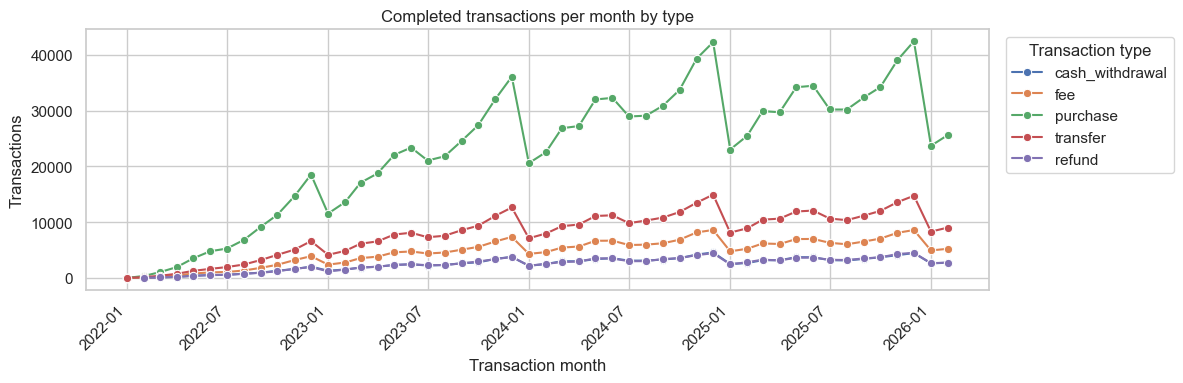

In [ ]:
tx_per_month = (
    df_tx.groupby(["transaction_month", "transaction_type"], as_index=False)
    .size()
    .rename(columns={"size": "tx_count"})
    .sort_values("transaction_month")
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=tx_per_month, x="transaction_month", y="tx_count", hue="transaction_type", marker="o", ax=ax)
ax.set_title("Completed transactions per month by type")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Transactions")
ax.legend(title="Transaction type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Completed transaction volume grows from near-zero in early 2022 to ~74k transactions/month by late 2025, with a clear step-up in run-rate during late 2025. The mix is heavily purchase-led, while transfers grow steadily and non-core types (fees, refunds, cash withdrawals) remain comparatively small. Seasonality plays a crucial role here.

**Business insights**
- **Revenue concentration:** Since purchase dominates volume, top-line performance is highly sensitive to purchase conversion and repeat usage; improving purchase retention likely delivers the largest revenue impact.
- **Operational planning:** The sharp late-2025 acceleration suggests capacity requirements (support, risk monitoring, payment processing) can rise quickly; forecasting should include surge scenarios rather than linear growth assumptions.
- **Product strategy:** Transfer growth indicates increasing wallet/account utility; bundling transfer-adjacent features can improve stickiness and raise monthly active engagement.
- **Risk and quality control:** As volume scales, even stable refund/fee rates can generate material absolute counts; track these as rate-based KPIs to protect margin and customer experience.



<a id="q5"></a>

<a id="Total-amount-per-month"></a>

### 5. Total amount per month by type

[↑ Back to summary](#summary)


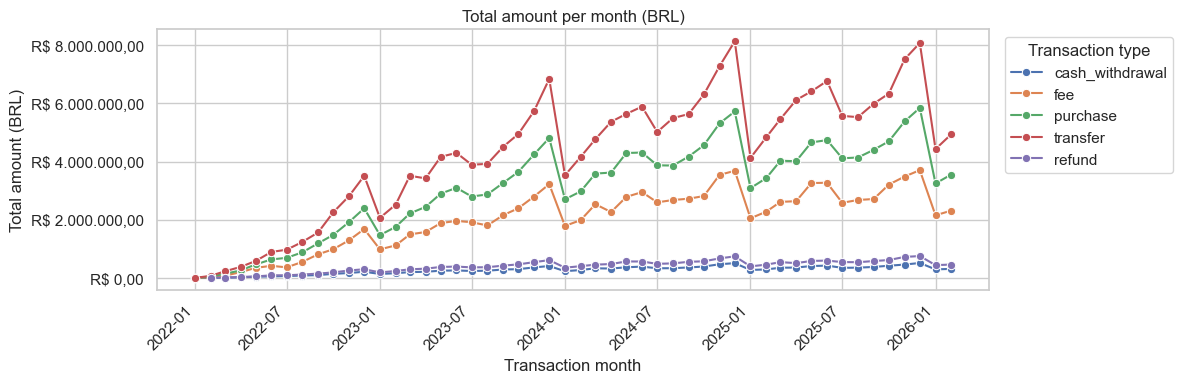

In [24]:

amount_per_month = (
    df_tx.groupby(["transaction_month", "transaction_type"], as_index=False)["amount"]
    .sum()
    .rename(columns={"amount": "total_amount"})
    .sort_values(["transaction_month", "transaction_type"])
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=amount_per_month, x="transaction_month", y="total_amount", hue="transaction_type", marker="o", ax=ax)
ax.set_title("Total amount per month (BRL)")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Total amount (BRL)")
ax.yaxis.set_major_formatter(FuncFormatter(format_brl))
ax.legend(title="Transaction type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Monthly **total amount (BRL)** starts near zero in early 2022 and builds into **~19MM** by dec **2025**. In **currency**, **transfer** sits **on top** for most of the window, **purchase** is **second**, and **fee**, **refund**, and **cash_withdrawal** are **much smaller** in aggregate BRL—so the **value** ranking of lines is **not** the same as a ranking by **how often** people transact. The series also shows a **recurring sawtooth**: softer **January** months and **stronger year‑end** months, i.e. clear **calendar seasonality** riding on top of growth.

**Compared to §4 (transactions per month by type):** The **count** chart is **purchase‑heavy**, but this **amount** chart is **transfer‑heavy in reais**—so **throughput of transactions** and **throughput of BRL** diverge: **higher purchase frequency** can coexist with **larger monthly transfer totals** when **average ticket** (and what sits behind each transaction type) differs. Use **§4 for activity / mix diagnostics** and **§5 for economic scale**; optimizing one does not automatically move the other.



<a id="q6"></a>

<a id="Unique-users-over-time"></a>

### 6. Unique users over time (MAU)

[↑ Back to summary](#summary)


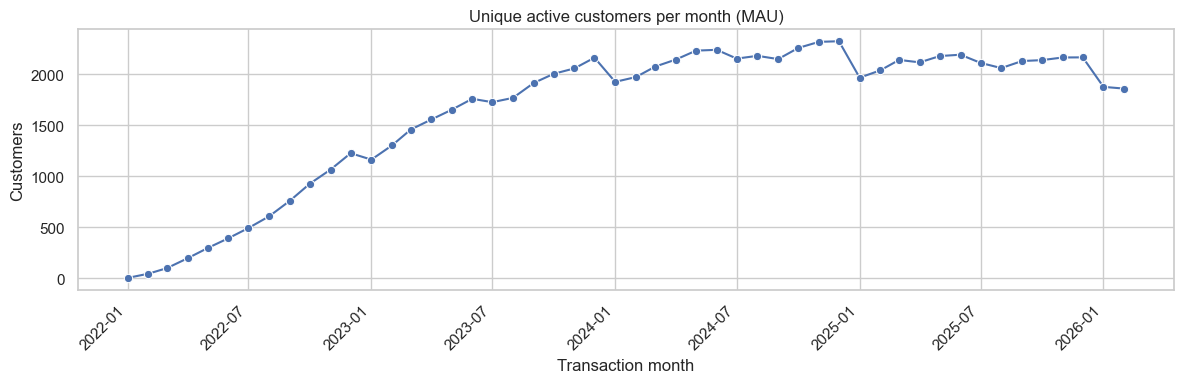

In [9]:

mau_per_month = (
    df_tx.groupby("transaction_month", as_index=False)["customer_id"]
    .nunique()
    .rename(columns={"customer_id": "mau"})
    .sort_values("transaction_month")
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=mau_per_month, x="transaction_month", y="mau", marker="o", ax=ax)
ax.set_title("Unique active customers per month (MAU)")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


<span style="color:red;">MAU broadly tracks TPV growth through 2023–2024, but the series **plateaus around ~2.1k–2.3k unique active customers/month** rather than scaling with the growing registered base. The channel and cohort breakdowns below clarify which acquisition cohorts are driving this ceiling.</span>


<a id="q7"></a>

<a id="Total-amount-per-channel"></a>

### 7. Total amount per channel over time (stacked)

[↑ Back to summary](#summary)


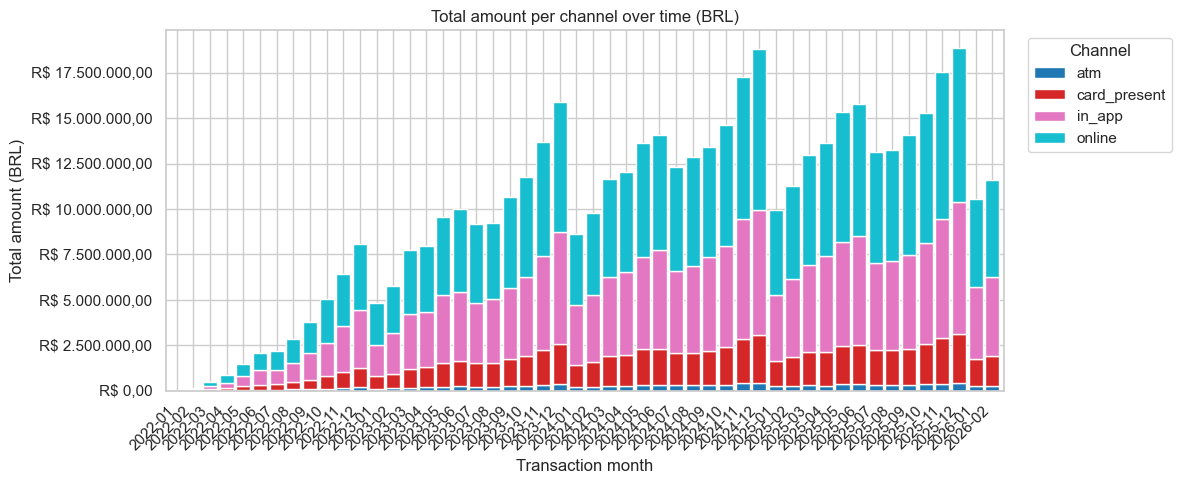

In [10]:

amount_pivot = (
    df_tx.pivot_table(
        index="transaction_month",
        columns="channel",
        values="amount",
        aggfunc="sum",
        fill_value=0,
    )
    .sort_index()
)

# Use categorical month labels for the x-axis (avoids pandas datetime/period plotting edge cases)
amount_pivot = amount_pivot.copy()
if isinstance(amount_pivot.index, pd.PeriodIndex):
    amount_pivot.index = amount_pivot.index.strftime("%Y-%m")
elif isinstance(amount_pivot.index, pd.DatetimeIndex):
    amount_pivot.index = amount_pivot.index.strftime("%Y-%m")
elif pd.api.types.is_period_dtype(amount_pivot.index):
    amount_pivot.index = pd.PeriodIndex(amount_pivot.index, freq="M").strftime("%Y-%m")
elif pd.api.types.is_datetime64_any_dtype(amount_pivot.index):
    amount_pivot.index = pd.to_datetime(amount_pivot.index).strftime("%Y-%m")
else:
    amount_pivot.index = amount_pivot.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
amount_pivot.plot(kind="bar", stacked=True, ax=ax, width=0.85, colormap="tab10")
ax.set_title("Total amount per channel over time (BRL)")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Total amount (BRL)")
ax.yaxis.set_major_formatter(FuncFormatter(format_brl))
ax.legend(title="Channel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Channel mix story:** **`in_app` and `online` contributes the largest share of incremental BRL** across the period and remains the core growth engine. **`card_present`**  also expand and provide diversification across payment contexts (physical and web), while **`atm`** stays comparatively small and declines in mix share over time.

**Business implication:** Prioritize reliability, fraud controls, limits strategy, and checkout UX in **`in_app`** and **`online`** (highest volume leverage). Use **`card_present`** to reduce concentration risk and support specific use cases. Keep **`atm`** optimized for niche cash-access journeys.

<a id="Average-ticket-by-month"></a>

### 8. Average ticket by month (by product type)

We compute **mean transaction amount** for each **`product_type`** in each **calendar month** — so you can compare **typical transaction size** across the product book (wallet, card, investment, etc.), separate from **how often** people transact (**§4**) or **total BRL** (**§5**).

[↑ Back to summary](#summary)


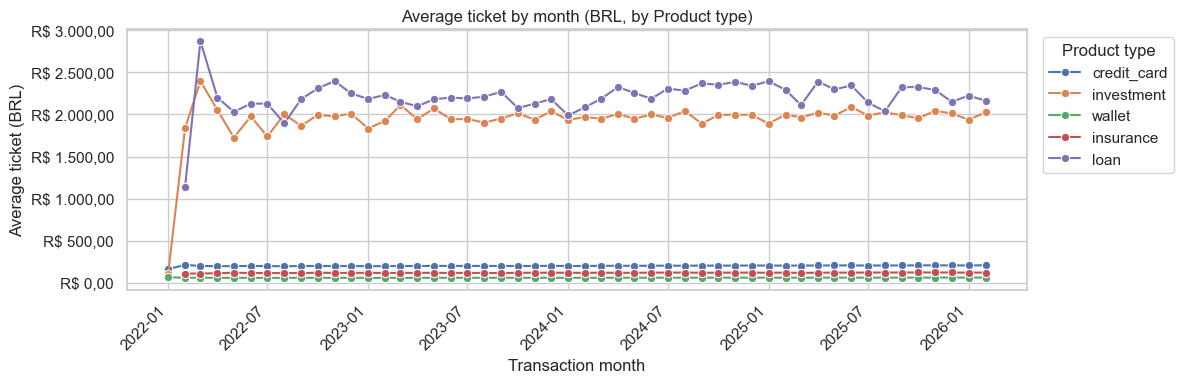

In [36]:
# ── Average ticket by month (by product type) ───────────────────────────────

avg_ticket = (
    df_tx.groupby(["transaction_month", "product_type"], as_index=False)["amount"]
    .mean()
    .rename(columns={"amount": "avg_ticket"})
    .sort_values(["transaction_month", "product_type"])
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(
    data=avg_ticket,
    x="transaction_month",
    y="avg_ticket",
    hue="product_type",
    marker="o",
    ax=ax,
)
ax.set_title("Average ticket by month (BRL, by product type)")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Average ticket (BRL)")
ax.yaxis.set_major_formatter(FuncFormatter(format_brl))
ax.legend(title="Product type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Takeaway:** The series falls into **two bands**: **`loan`** and **`investment`** carry **much larger average tickets** (large disbursements / deposits), while **`credit_card`**, **`insurance`**, and **`wallet`** sit **far lower** — everyday spending, premiums, and small wallet movements. That gap is **structural to the product economics** in this portfolio, not a month-to-month “surprise.” After the **early-2022 ramp** (fewer transactions per month per line), each product’s **typical ticket is fairly stable** — so **growth levers** are mostly **volume and mix** (who holds which product), not steady ticket inflation. Read **§4–§5** alongside this: **high tx counts** with **flat average ticket** still lift TPV; compare **§6** (breadth of actives) with **§5** (total TPV) to see whether growth is **more active customers** vs **more spend through volume or product mix**.



<a id="part-3"></a>

## Part 3 — Cohort analysis (M3 + M6 retention by registration month)

**Goal:** measure **retention quality** at **M3** and **M6** by **`cohort_month`** and **`acquisition_channel`**, using the **full customer roster** and completed transaction activity only.

[↑ Back to summary](#summary)



We compare eligible **cohort months** using **cohort size** and retention KPIs at **M3** and **M6**—each cohort is a registration (acquisition) month.

We measure retention by **cohort month**: `cohort_month` is `registration_date` truncated to month start. **M0** is the registration month; **M1..M6** are subsequent calendar months (tenure slots).

A customer is **active** in a slot if they have at least one **completed** transaction in that calendar month.

**KPIs used in this section**

- **`m3_active_rate` / `m6_active_rate`:** share of cohort members active in M3 / M6.
- **`strict_streak_m3_rate`:** share active in all of M0..M3.
- **`strict_streak_m6_rate`:** share active in all of M0..M6.

**Eligibility:** each KPI uses its own observable denominator. A customer enters M3 metrics only if `cohort_month + 3 months <= latest_complete_month`; similarly for M6 with `+ 6 months`.

**Design choices:** (1) The cohort roster comes from **`df_customers`** (all customers), not from **`df_tx`**. The latter is an inner join on completed transactions, so customers with zero completed transactions would disappear from denominators if cohorts came only from `df_tx`. (2) We detect activity by **absence vs presence**: each row in `df_tx` is a real completed transaction, so inactive months do not appear. We build a **customer × M0..M6** expected grid and **left-join** observed transaction months; no match means inactive for that month. (3) For cohort-level comparisons (retention curves, LTV), the safest core window is **Jan 2023 - Sep 2025**: pre-2023 cohorts may reflect a different acquisition motion and product maturity stage, while cohorts registered after Sep 2025 have fewer than 6 months of observable behavior (cold-start zone).


Preparing the data for the cohort analysis...

In [37]:
# Safe comparison window for cohort-level analyses
window_start = pd.Timestamp("2023-01-01")
window_end = pd.Timestamp("2026-02-28")

In [38]:

# Full cohort roster from all customers; observed active months from completed tx only
reg = df_customers["registration_date"]
if isinstance(reg.dtype, pd.DatetimeTZDtype):
    reg = reg.dt.tz_convert("UTC").dt.tz_localize(None)

customers = df_customers[["customer_id", "acquisition_channel"]].copy()
customers["cohort_month"] = reg.dt.to_period("M").dt.to_timestamp()

df_tx_window = df_tx[df_tx["transaction_month"].between(window_start, window_end)].copy()

actual_active = (
    df_tx_window.groupby(["customer_id", "transaction_month"])
    .size()
    .reset_index(name="tx_count")
    .rename(columns={"transaction_month": "calendar_month"})
    .assign(has_tx=True)[["customer_id", "calendar_month", "has_tx"]]
)


In [39]:

# Parameter block for retention horizons
RETENTION_HORIZONS = [3, 6]
MAX_TENURE = max(RETENTION_HORIZONS)

# Use the selected analysis window consistently
customers_window = customers[
    customers["cohort_month"].between(window_start, window_end)
].copy()
latest_complete_month = df_tx_window["transaction_month"].max().to_period("M")

# Expected M0..M6 grid: cross-product of customers × tenure slots, left-join
# observed activity, pivot to one row per customer with m0..m6 booleans.
tenure_df = pd.DataFrame({"tenure_index": list(range(MAX_TENURE + 1))})
cust_for_grid = customers_window.copy()
cust_for_grid["_key"] = 1
tenure_df["_key"] = 1
grid = cust_for_grid.merge(tenure_df, on="_key").drop(columns="_key")

# Expected calendar month for each slot (normalized to first-of-month)
grid["calendar_month"] = grid.apply(
    lambda r: r["cohort_month"] + pd.DateOffset(months=int(r["tenure_index"])),
    axis=1,
)
grid["calendar_month"] = grid["calendar_month"].dt.to_period("M").dt.to_timestamp()

# Left join: no match means no completed transaction in that month
grid = grid.merge(actual_active, on=["customer_id", "calendar_month"], how="left")
grid["has_tx"] = grid["has_tx"].fillna(False)

pivot = grid.pivot_table(
    index=["customer_id", "cohort_month", "acquisition_channel"],
    columns="tenure_index",
    values="has_tx",
    aggfunc="max",
    fill_value=False,
).reset_index()
pivot.columns.name = None

# Normalize dynamic tenure columns to m0..m6 names
rename_map = {i: f"m{i}" for i in range(MAX_TENURE + 1)}
pivot = pivot.rename(columns=rename_map)
for i in range(MAX_TENURE + 1):
    col = f"m{i}"
    if col not in pivot.columns:
        pivot[col] = False

# Horizon-specific eligibility masks (per customer)
for h in RETENTION_HORIZONS:
    h_month = (pivot["cohort_month"] + pd.DateOffset(months=h)).dt.to_period("M")
    pivot[f"eligible_h{h}"] = h_month <= latest_complete_month

# Horizon-specific strict streak flags
pivot["strict_streak_m3"] = pivot[["m0", "m1", "m2", "m3"]].all(axis=1)
pivot["strict_streak_m6"] = pivot[[f"m{i}" for i in range(7)]].all(axis=1)

pivot.head()


,customer_id,cohort_month,acquisition_channel,m0,m1,m2,m3,m4,m5,m6,eligible_h3,eligible_h6,strict_streak_m3,strict_streak_m6
0,0008b8e6-4f17-4201-8db1-a2475dbf6af8,2023-11-01,partnership,False,False,False,True,False,False,False,True,True,False,False
1,0008f2f8-6249-443b-ac7b-4c09c35e0322,2025-09-01,organic,False,True,False,True,False,False,False,True,False,False,False
2,00165c70-34b5-4ba0-8206-28f1d861c239,2024-12-01,organic,True,False,False,True,False,False,False,True,True,False,False
3,0017a837-4356-4c10-b307-32f6f09525ab,2024-05-01,referral,False,True,True,True,True,True,True,True,True,False,False
4,002970a6-338e-435d-af6c-4e3f7465f76c,2024-08-01,organic,True,True,False,True,True,True,True,True,True,False,False


In [40]:

# Cohort KPI table with horizon-specific denominators
agg_rows = []
for cohort_month, g in pivot.groupby("cohort_month"):
    row = {"cohort_month": cohort_month}

    g3 = g[g["eligible_h3"]]
    row["eligible_n_h3"] = int(len(g3))
    row["m3_active_count"] = int(g3["m3"].sum())
    row["strict_streak_m3_count"] = int(g3["strict_streak_m3"].sum())
    row["m3_active_rate"] = row["m3_active_count"] / row["eligible_n_h3"] if row["eligible_n_h3"] else np.nan
    row["strict_streak_m3_rate"] = (
        row["strict_streak_m3_count"] / row["eligible_n_h3"] if row["eligible_n_h3"] else np.nan
    )

    g6 = g[g["eligible_h6"]]
    row["eligible_n_h6"] = int(len(g6))
    row["m6_active_count"] = int(g6["m6"].sum())
    row["strict_streak_m6_count"] = int(g6["strict_streak_m6"].sum())
    row["m6_active_rate"] = row["m6_active_count"] / row["eligible_n_h6"] if row["eligible_n_h6"] else np.nan
    row["strict_streak_m6_rate"] = (
        row["strict_streak_m6_count"] / row["eligible_n_h6"] if row["eligible_n_h6"] else np.nan
    )

    agg_rows.append(row)

cohort_kpi = pd.DataFrame(agg_rows).sort_values("cohort_month").reset_index(drop=True)

# Q2 helper rankings: quality (rate) and volume (retained count)
q2_rank_m6_rate = cohort_kpi.dropna(subset=["m6_active_rate"]).sort_values(
    ["m6_active_rate", "eligible_n_h6"], ascending=[False, False]
)[["cohort_month", "eligible_n_h6", "m6_active_count", "m6_active_rate"]]

q2_rank_m6_volume = cohort_kpi.dropna(subset=["m6_active_rate"]).sort_values(
    ["m6_active_count", "m6_active_rate"], ascending=[False, False]
)[["cohort_month", "eligible_n_h6", "m6_active_count", "m6_active_rate"]]



<a id="bq2"></a>

### Roadmap Q2 — Which acquisition month produces the most retained customers?

Reading the ranking tables below:
- **Top cohort months by M6 retention rate** (quality)
    June 2024
- **Top cohort months by retained users at M6** (volume)
    March 2023

Older windows often dominate **volume at M6** simply because more users had time to reach M6 and cohorts were larger; **quality** (M6 rate) can still peak in a more recent month (e.g. mid-2024), so “best month” depends on whether you optimize **efficiency** vs **absolute retained headcount**.

**Actionable insight:** (1) **Budget and targets:** use the **rate** leaderboard to benchmark acquisition quality and set **minimum M6-rate** guardrails by channel; use the **volume** leaderboard to understand where **scale** came from historically, not necessarily where to copy-paste spend today. (2) **Playbooks:** run a **post-mortem** on top months (mix, campaigns, product changes) and document **replicable** tactics vs one-off seasonality. (3) **Governance:** when comparing months, always read alongside **eligible N**—small denominators can inflate rates; prioritize decisions where **both** rate and N are healthy.

In [42]:
print("Top cohort months by M6 retention rate")
display(q2_rank_m6_rate.head(8))

print("Top cohort months by retained users count at M6")
display(q2_rank_m6_volume.head(8))

Top cohort months by M6 retention rate


,cohort_month,eligible_n_h6,m6_active_count,m6_active_rate
17,2024-06-01,143,78,0.545455
16,2024-05-01,161,85,0.527950
11,2023-12-01,204,107,0.524510
31,2025-08-01,64,33,0.515625
29,2025-06-01,74,38,0.513514
10,2023-11-01,205,104,0.507317
26,2025-03-01,92,46,0.500000
3,2023-04-01,240,119,0.495833


Top cohort months by retained users count at M6


,cohort_month,eligible_n_h6,m6_active_count,m6_active_rate
2,2023-03-01,279,130,0.465950
0,2023-01-01,276,127,0.460145
3,2023-04-01,240,119,0.495833
1,2023-02-01,246,118,0.479675
7,2023-08-01,238,108,0.453782
11,2023-12-01,204,107,0.524510
5,2023-06-01,238,107,0.449580
10,2023-11-01,205,104,0.507317



<a id="bq3"></a>

### Roadmap Q3 — At what month do most customers disengage?

We estimate disengagement timing with a tenure retention curve (`M0..M6`) over M6-eligible customers. The largest month-to-month drop indicates where disengagement is most concentrated.


Largest disengagement window: M4 -> M5 (drop=3.03%)


,tenure_month,retention_rate,drop_from_prev
0,0,0.298637,NaN
1,1,0.578917,-0.280280
2,2,0.551287,0.027631
3,3,0.529712,0.021575
4,4,0.509084,0.020628
5,5,0.478804,0.030280
6,6,0.460447,0.018357


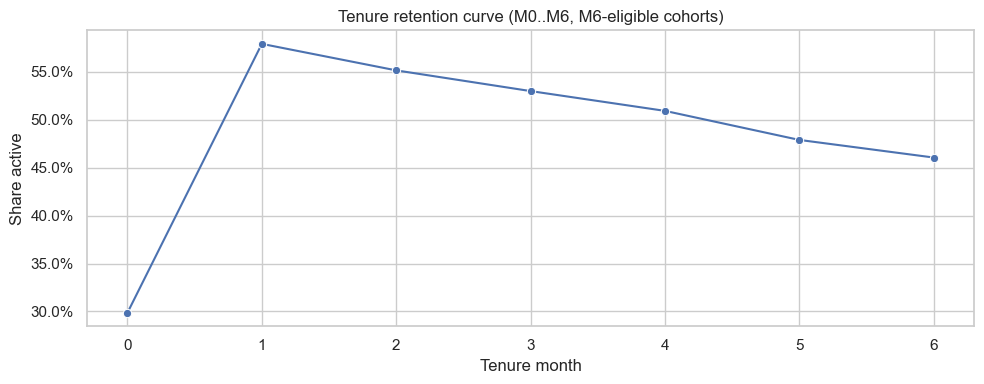

In [43]:

# Q3: tenure retention and drop-off on M6-eligible population
pivot_m6 = pivot[pivot["eligible_h6"]].copy()
retention_by_tenure = pd.DataFrame(
    {
        "tenure_month": list(range(7)),
        "retention_rate": [pivot_m6[f"m{i}"].mean() for i in range(7)],
    }
)
retention_by_tenure["drop_from_prev"] = retention_by_tenure["retention_rate"].shift(1) - retention_by_tenure[
    "retention_rate"
]

largest_drop_row = retention_by_tenure.loc[retention_by_tenure["drop_from_prev"].idxmax()]
print(
    f"Largest disengagement window: M{int(largest_drop_row['tenure_month']) - 1} -> M{int(largest_drop_row['tenure_month'])} "
    f"(drop={largest_drop_row['drop_from_prev']:.2%})"
)

display(retention_by_tenure)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=retention_by_tenure, x="tenure_month", y="retention_rate", marker="o", ax=ax)
ax.set_title("Tenure retention curve (M0..M6, M6-eligible cohorts)")
ax.set_xlabel("Tenure month")
ax.set_ylabel("Share active")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xticks(range(7))
plt.tight_layout()
plt.show()


**Chart read — tenure curve (M6-eligible cohorts only):** This is a **single aggregate** lifecycle: share of customers with **at least one completed transaction** in each tenure month (M0..M6), among cohorts that are **eligible through M6** (same denominator logic as elsewhere). It does **not** compare “recent vs older” cohorts; for that, split by `cohort_month` or acquisition channel.

**Pattern:** Activity is **lowest at M0** (~low-30s % share) then **jumps sharply by M1** (toward ~60%), which is consistent with **delayed first use** (onboarding lag, setup, or first spend not landing in the registration month) rather than “weak” users at signup. After M1, the curve **declines steadily** through M6 (~mid-40s %), i.e. **ongoing churn / intermittency** within the first half-year.

The steepest **marginal drop** after M1 is **M4→M5** (~3.03 pp)—prioritize retention and habit experiments in that window.

**Actionable insight:** (1) **M0→M1:** shorten time-to-first-value with in-app prompts, KYC/funding nudges, and lifecycle email/SMS timed to days 1–7 so more users show activity in the registration month if that is strategically important. (2) **M4→M5:** treat this as the **first critical post-activation cliff**—run win-back and engagement campaigns (limits, rewards, recurring payments) for users who were active early but go quiet. (3) **Measure:** track cohort experiments on **M1 and M3 active rates** separately so onboarding fixes are not confounded with mid-tenure churn. (4) **Segment:** repeat this curve by `acquisition_channel` to avoid optimizing the average while a high-spend channel underperforms.



<a id="bq4"></a>

### Roadmap Q4 — Are recent cohorts healthier than older ones?

As we can see in the following chart, at the overall cohort level, we do not see a clear directional pattern in M3/M6 or strict streak rates; the series looks volatile without a sustained trend. That suggests we should not over-interpret month-to-month moves without uncertainty bands or splits. Separately, the shrinking eligible cohort size points to an acquisition/volume story that deserves its own diagnosis.

[↑ Back to summary](#summary)



<a id="bqn"></a>

### Cohort KPIs over time

We evaluate cohort quality with **M3** and **M6** active checkpoints plus strict streak variants (**M0..M3** and **M0..M6**). **M6** is the stronger quality test with this history, while **M3** remains an early leading indicator.

The second panel shows eligible denominator by horizon, so trend changes can be interpreted alongside sample support.

[↑ Back to summary](#summary)


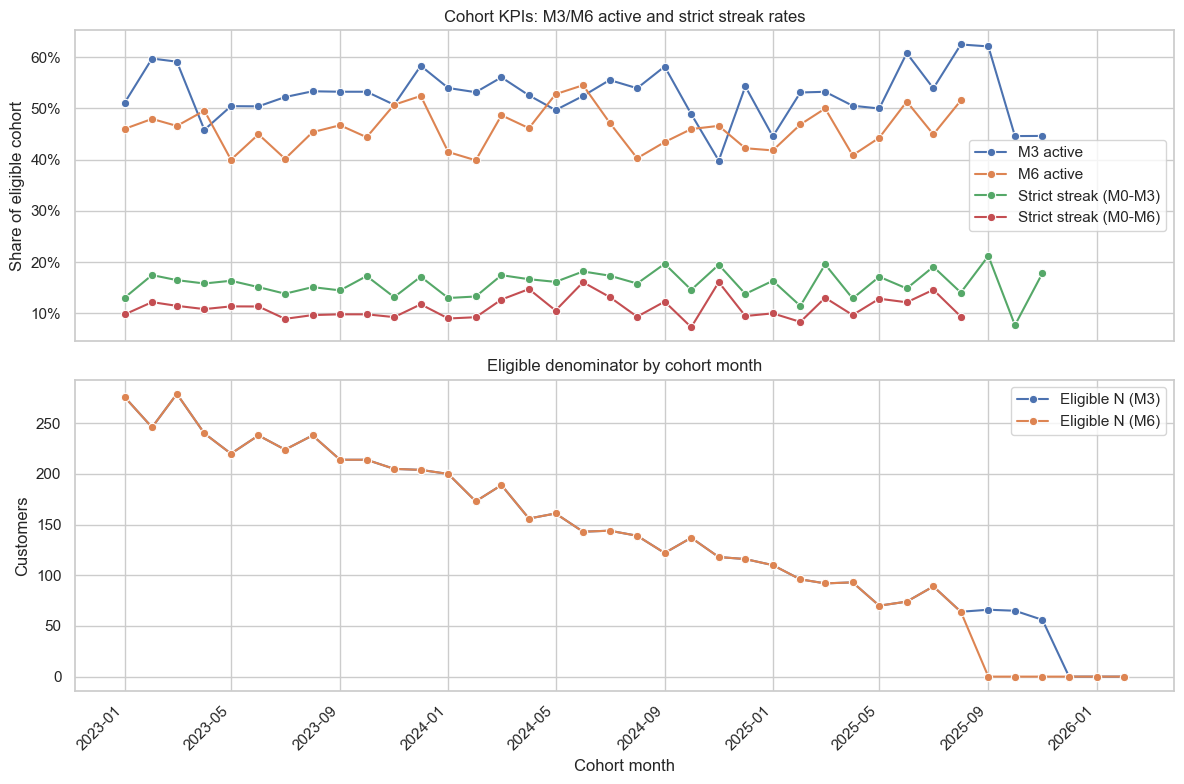

In [44]:

plot_kpi = cohort_kpi.sort_values("cohort_month").copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

kpi_long = plot_kpi.melt(
    id_vars=["cohort_month"],
    value_vars=["m3_active_rate", "m6_active_rate", "strict_streak_m3_rate", "strict_streak_m6_rate"],
    var_name="kpi",
    value_name="rate",
)
kpi_long["kpi"] = kpi_long["kpi"].map(
    {
        "m3_active_rate": "M3 active",
        "m6_active_rate": "M6 active",
        "strict_streak_m3_rate": "Strict streak (M0-M3)",
        "strict_streak_m6_rate": "Strict streak (M0-M6)",
    }
)

sns.lineplot(
    data=kpi_long,
    x="cohort_month",
    y="rate",
    hue="kpi",
    marker="o",
    ax=ax1,
)
ax1.set_title("Cohort KPIs: M3/M6 active and strict streak rates")
ax1.set_ylabel("Share of eligible cohort")
ax1.set_xlabel("")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.legend(title=None, loc="best")

sns.lineplot(
    data=plot_kpi,
    x="cohort_month",
    y="eligible_n_h3",
    marker="o",
    label="Eligible N (M3)",
    ax=ax2,
)
sns.lineplot(
    data=plot_kpi,
    x="cohort_month",
    y="eligible_n_h6",
    marker="o",
    label="Eligible N (M6)",
    ax=ax2,
)
ax2.set_title("Eligible denominator by cohort month")
ax2.set_ylabel("Customers")
ax2.set_xlabel("Cohort month")
ax2.legend(title=None, loc="best")

for ax in (ax1, ax2):
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

fig.tight_layout()
plt.show()



<a id="bq5"></a>

### Roadmap Q5 - Which acquisition channel brings the highest quality customers?

Using the same roster and eligibility rules, we group by **`cohort_month`** and **`acquisition_channel`** and compute **M6 active rate** and **strict streak M0..M6** as primary quality metrics, with M3 as a secondary signal. The ranking table is weighted by eligible cohort size and ordered by M6 first, then M3.

[↑ Back to summary](#summary)


In [45]:

# Channel KPI table with horizon-specific denominators
ch_rows = []
for (cohort_month, channel), g in pivot.groupby(["cohort_month", "acquisition_channel"]):
    row = {"cohort_month": cohort_month, "acquisition_channel": channel}

    g3 = g[g["eligible_h3"]]
    row["eligible_n_h3"] = int(len(g3))
    row["m3_active_count"] = int(g3["m3"].sum())
    row["strict_streak_m3_count"] = int(g3["strict_streak_m3"].sum())
    row["m3_active_rate"] = row["m3_active_count"] / row["eligible_n_h3"] if row["eligible_n_h3"] else np.nan
    row["strict_streak_m3_rate"] = (
        row["strict_streak_m3_count"] / row["eligible_n_h3"] if row["eligible_n_h3"] else np.nan
    )

    g6 = g[g["eligible_h6"]]
    row["eligible_n_h6"] = int(len(g6))
    row["m6_active_count"] = int(g6["m6"].sum())
    row["strict_streak_m6_count"] = int(g6["strict_streak_m6"].sum())
    row["m6_active_rate"] = row["m6_active_count"] / row["eligible_n_h6"] if row["eligible_n_h6"] else np.nan
    row["strict_streak_m6_rate"] = (
        row["strict_streak_m6_count"] / row["eligible_n_h6"] if row["eligible_n_h6"] else np.nan
    )

    ch_rows.append(row)

channel_kpi = pd.DataFrame(ch_rows).sort_values(["cohort_month", "acquisition_channel"]).reset_index(drop=True)

# Q5 helper ranking: M6-first quality ranking by channel
channel_rank = (
    channel_kpi.dropna(subset=["m6_active_rate"])
    .groupby("acquisition_channel")
    .apply(
        lambda g: pd.Series(
            {
                "eligible_n_h6": g["eligible_n_h6"].sum(),
                "m6_active_rate_weighted": np.average(g["m6_active_rate"], weights=g["eligible_n_h6"]),
                "m3_active_rate_weighted": np.average(g["m3_active_rate"], weights=g["eligible_n_h3"]),
            }
        )
    )
    .reset_index()
    .sort_values(["m6_active_rate_weighted", "m3_active_rate_weighted"], ascending=False)
)

display(channel_kpi.tail(10))
print("Channel quality ranking (M6 primary, M3 secondary)")
display(channel_rank)


,cohort_month,acquisition_channel,eligible_n_h3,m3_active_count,strict_streak_m3_count,m3_active_rate,strict_streak_m3_rate,eligible_n_h6,m6_active_count,strict_streak_m6_count,m6_active_rate,strict_streak_m6_rate
142,2025-12-01,partnership,0,0,0,NaN,NaN,0,0,0,NaN,NaN
143,2025-12-01,referral,0,0,0,NaN,NaN,0,0,0,NaN,NaN
144,2026-01-01,organic,0,0,0,NaN,NaN,0,0,0,NaN,NaN
145,2026-01-01,paid_ads,0,0,0,NaN,NaN,0,0,0,NaN,NaN
146,2026-01-01,partnership,0,0,0,NaN,NaN,0,0,0,NaN,NaN
147,2026-01-01,referral,0,0,0,NaN,NaN,0,0,0,NaN,NaN
148,2026-02-01,organic,0,0,0,NaN,NaN,0,0,0,NaN,NaN
149,2026-02-01,paid_ads,0,0,0,NaN,NaN,0,0,0,NaN,NaN
150,2026-02-01,partnership,0,0,0,NaN,NaN,0,0,0,NaN,NaN
151,2026-02-01,referral,0,0,0,NaN,NaN,0,0,0,NaN,NaN


Channel quality ranking (M6 primary, M3 secondary)


,acquisition_channel,eligible_n_h6,m6_active_rate_weighted,m3_active_rate_weighted
3,referral,1242.0,0.642512,0.707729
2,partnership,1278.0,0.488263,0.541471
0,organic,1352.0,0.427515,0.511834
1,paid_ads,1412.0,0.306657,0.379603


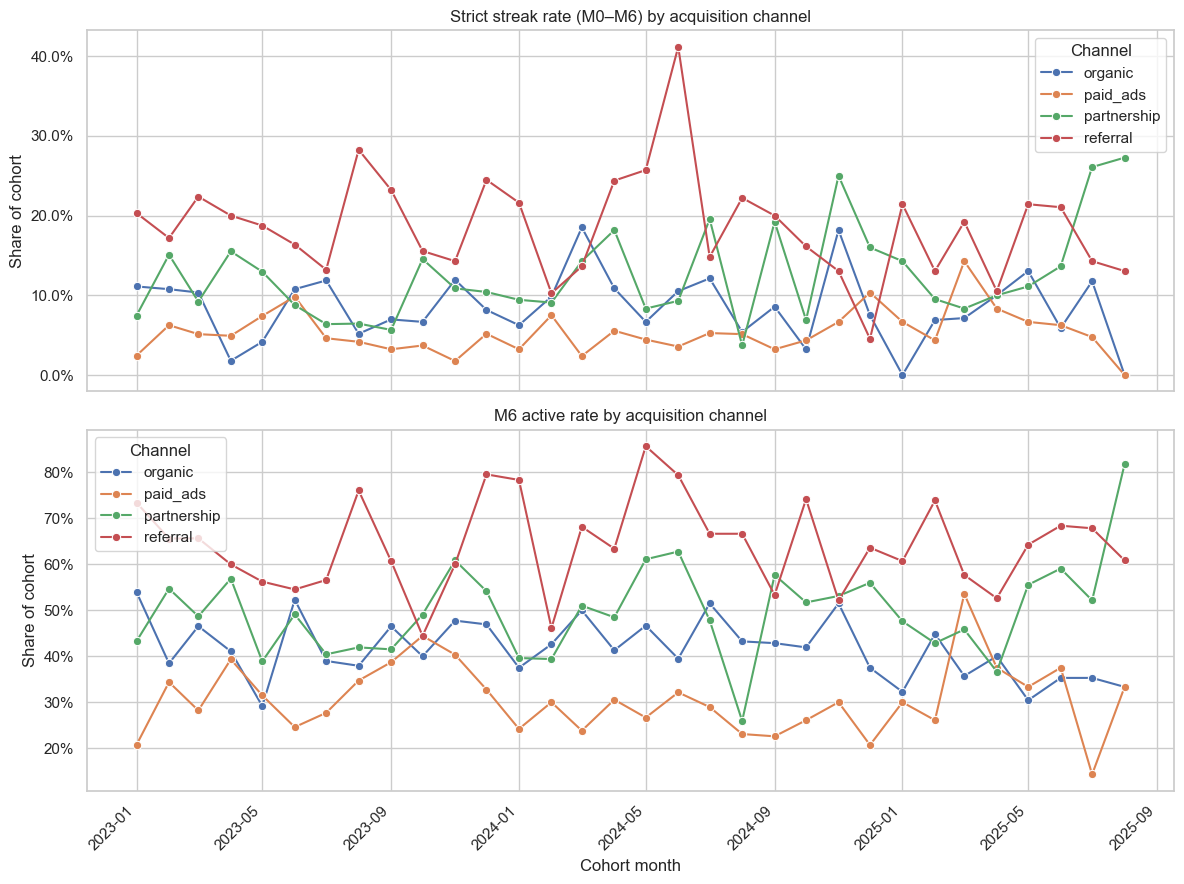

In [46]:

plot_ch = channel_kpi.sort_values(["cohort_month", "acquisition_channel"]).copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

sns.lineplot(
    data=plot_ch,
    x="cohort_month",
    y="strict_streak_m6_rate",
    hue="acquisition_channel",
    marker="o",
    ax=ax1,
)
ax1.set_title("Strict streak rate (M0–M6) by acquisition channel")
ax1.set_ylabel("Share of cohort")
ax1.set_xlabel("")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.legend(title="Channel", loc="best")

sns.lineplot(
    data=plot_ch,
    x="cohort_month",
    y="m6_active_rate",
    hue="acquisition_channel",
    marker="o",
    ax=ax2,
)
ax2.set_title("M6 active rate by acquisition channel")
ax2.set_ylabel("Share of cohort")
ax2.set_xlabel("Cohort month")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.legend(title="Channel", loc="best")

for ax in (ax1, ax2):
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

fig.tight_layout()
plt.show()


### Rolling average of channel cohort rates (reduces month-to-month noise)

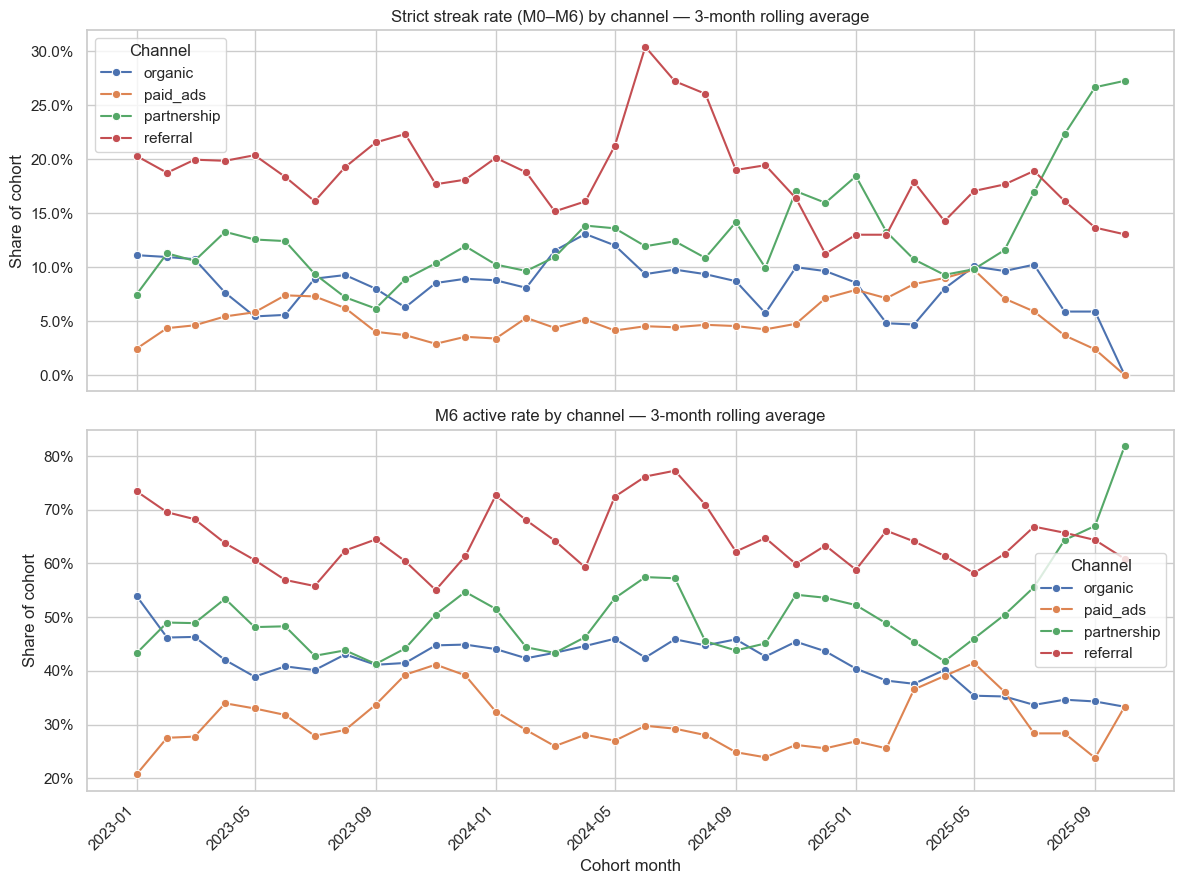

In [47]:

# Rolling average of channel cohort rates (reduces month-to-month noise)
ROLLING_MONTHS = 3

smooth_ch = plot_ch.sort_values(["acquisition_channel", "cohort_month"]).copy()
smooth_ch["strict_streak_m6_roll"] = smooth_ch.groupby("acquisition_channel")[
    "strict_streak_m6_rate"
].transform(lambda s: s.rolling(ROLLING_MONTHS, min_periods=1).mean())
smooth_ch["m6_active_roll"] = smooth_ch.groupby("acquisition_channel")[
    "m6_active_rate"
].transform(lambda s: s.rolling(ROLLING_MONTHS, min_periods=1).mean())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

sns.lineplot(
    data=smooth_ch,
    x="cohort_month",
    y="strict_streak_m6_roll",
    hue="acquisition_channel",
    marker="o",
    ax=ax1,
)
ax1.set_title(
    f"Strict streak rate (M0–M6) by channel — {ROLLING_MONTHS}-month rolling average"
)
ax1.set_ylabel("Share of cohort")
ax1.set_xlabel("")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.legend(title="Channel", loc="best")

sns.lineplot(
    data=smooth_ch,
    x="cohort_month",
    y="m6_active_roll",
    hue="acquisition_channel",
    marker="o",
    ax=ax2,
)
ax2.set_title(f"M6 active rate by channel — {ROLLING_MONTHS}-month rolling average")
ax2.set_ylabel("Share of cohort")
ax2.set_xlabel("Cohort month")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.legend(title="Channel", loc="best")

for ax in (ax1, ax2):
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

fig.tight_layout()
plt.show()


**Chart read (3-month rolling average, by `acquisition_channel`):** Top panel = **strict streak (M0–M6)**—share of each cohort that stayed active **every** month through M6. Bottom panel = **M6 active rate**—share active in month 6 **whether or not** they were active in between. Same cohort axis, so you can compare **consistency** vs **late survival** side by side.

**What this window shows:** **Referral** is the **historical leader** on both panels—**M6 active** mostly in a high band (roughly mid‑50s–high‑70s %), with **strict streak** strongest through the mid‑window and **some softening** in the latest rolling points. **Partnership** sits **mid-pack** for much of the series but shows a **sharp lift in late 2025** on **both** streak and M6 (including a very high **M6** spike at the end)—treat that endpoint as **validation-first** (eligible **N**, partner program changes, promo mix, and any **cohort-size** effects) before re-rating the channel. **Organic** shows a **long downward drift** on **M6** from earlier cohorts toward the tail, while streak fluctuates in a **moderate** band—consistent with a **broad channel** whose late cohorts need **mix and product** diagnosis, not a single KPI. **Paid_ads** is **consistently weakest** on **M6** and shows the **streak line collapsing toward the last cohorts**—a red flag for **quality and/or mix**, not only volume.

**Actionable insight:** (1) **Referral:** keep as the **benchmark** for M6 and streak; investigate **why** the newest rolling averages ease vs the mid‑2024 peak (incentives, fraud, or cohort mix). (2) **Partnership:** for the **late‑2025 surge**, confirm **denominator**, **partner launches**, and **deal terms**; if confirmed, codify the playbook and **watch streak vs M6** together so a thin high‑engagement tail is not mistaken for broad health. (3) **Paid_ads:** run a **full-funnel audit** (creative, audience, geo, landing) and enforce **minimum M6 / streak guardrails**; the **near‑zero streak** at the tail warrants **pause-or-fix** rules until quality recovers. (4) **Organic:** prioritize **retention levers** (activation, pricing perception, competitive pressure) behind the **M6 slide**, not just top‑of‑funnel volume. (5) **Governance:** publish **channel-level** M6 and streak targets, review **acquisition mix** monthly, and **never** optimize blended retention while **paid** or **tail cohorts** deteriorate.


## Part 3 — Behavioral Discovery: Finding Natural Customer Groups <a id="part3"></a>
> This section explores the customer base through observable behavioral signals only.
> The goal is to discover natural fault lines before formal clustering 
> (Notebook 3). Each analysis ends with a hypothesis for the clustering step.

Jump to:
- [3.1 — Behavioral Heterogeneity](#h31)
- [3.2 — Seasonality Residuals](#h32)
- [3.3 — Activation Quality Tiers](#h33)
- [3.4 — Recency-Based Risk Tiers](#h34)
- [3.5 — Frequency Quality Tiers](#h35)
- [3.6 — Product Adoption Curves](#h36)
- [3.7 — Cohort Revenue Curves](#h37)
- [3.8 — Churn Proxies](#h38)


### 3.1 — Behavioral Heterogeneity: Is this customer base uniform or naturally segmented? <a id="h31"></a>
> If all customers behave similarly, the activity rate distribution should be unimodal and symmetric.
> Multiple peaks or heavy tails signal distinct behavioral populations.


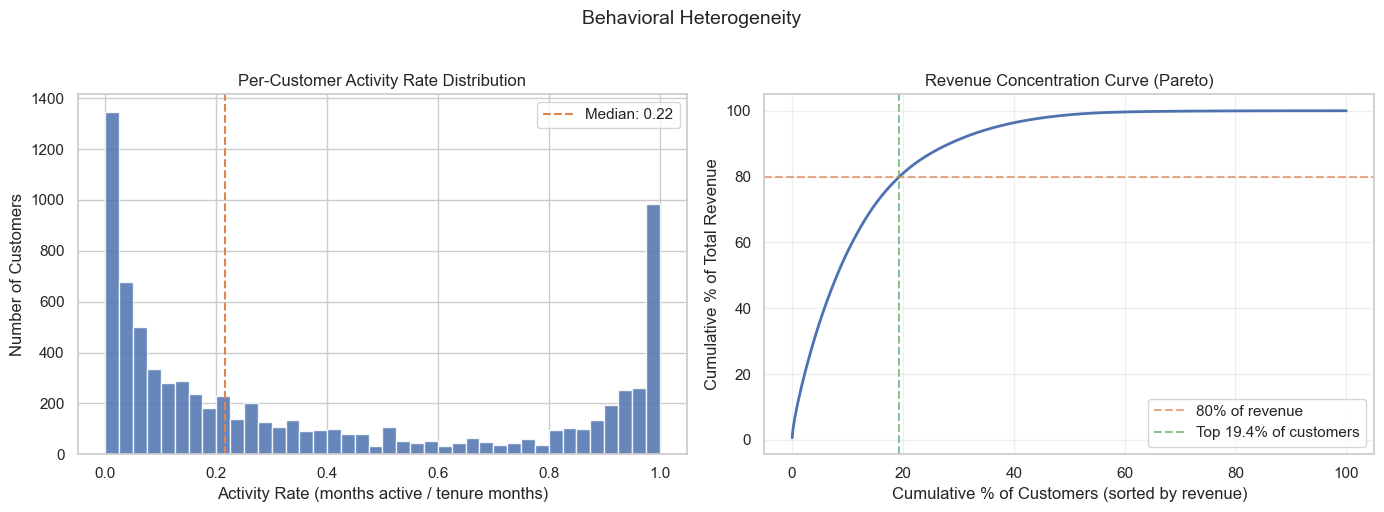

Activity rate summary:
count    8000.000
mean        0.385
std         0.381
min         0.000
25%         0.048
50%         0.216
75%         0.833
max         1.000
Name: activity_rate, dtype: float64

Top 20% of customers drive 81.0% of total revenue


In [50]:
# Per-customer activity rate: months with ≥1 transaction / tenure months
# Align timezones: transaction_month is often tz-naive while registration_date from DB may be tz-aware.
ref_ts = pd.Timestamp(df_tx["transaction_month"].max())
if ref_ts.tzinfo is not None:
    ref_ts = ref_ts.tz_convert(None)

customer_tenure = df_customers.copy()
reg_dates = pd.to_datetime(customer_tenure["registration_date"])
if reg_dates.dt.tz is not None:
    reg_dates = reg_dates.dt.tz_convert(None)

customer_tenure["tenure_months"] = (
    (ref_ts - reg_dates).dt.days / 30.44
).clip(lower=1).round(0).astype(int)

months_active = (
    df_tx[df_tx["status"] == "completed"]
    .groupby("customer_id")["transaction_month"]
    .nunique()
    .reset_index(name="months_active")
)

customer_activity = customer_tenure.merge(months_active, on="customer_id", how="left")
customer_activity["months_active"] = customer_activity["months_active"].fillna(0)
customer_activity["activity_rate"] = (
    customer_activity["months_active"] / customer_activity["tenure_months"]
).clip(upper=1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: activity rate distribution
axes[0].hist(customer_activity["activity_rate"], bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(customer_activity["activity_rate"].median(), color="#DD8452", linestyle="--", label=f"Median: {customer_activity['activity_rate'].median():.2f}")
axes[0].set_xlabel("Activity Rate (months active / tenure months)")
axes[0].set_ylabel("Number of Customers")
axes[0].set_title("Per-Customer Activity Rate Distribution")
axes[0].legend()

# Right: Pareto — revenue concentration
tx_complete = df_tx[df_tx["status"] == "completed"]
customer_revenue = (
    tx_complete.groupby("customer_id")["amount"].sum()
    .sort_values(ascending=False)
    .reset_index(name="total_revenue")
)
customer_revenue["cumulative_pct"] = customer_revenue["total_revenue"].cumsum() / customer_revenue["total_revenue"].sum() * 100
customer_revenue["customer_pct"] = (customer_revenue.index + 1) / len(customer_revenue) * 100

axes[1].plot(customer_revenue["customer_pct"], customer_revenue["cumulative_pct"], color="#4C72B0", linewidth=2)
axes[1].axhline(80, color="#DD8452", linestyle="--", alpha=0.7, label="80% of revenue")
# find the x where cumulative hits 80%
pct_customers_for_80 = customer_revenue.loc[customer_revenue["cumulative_pct"] >= 80, "customer_pct"].iloc[0]
axes[1].axvline(pct_customers_for_80, color="#55A868", linestyle="--", alpha=0.7, label=f"Top {pct_customers_for_80:.1f}% of customers")
axes[1].set_xlabel("Cumulative % of Customers (sorted by revenue)")
axes[1].set_ylabel("Cumulative % of Total Revenue")
axes[1].set_title("Revenue Concentration Curve (Pareto)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Behavioral Heterogeneity", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Activity rate summary:")
print(customer_activity["activity_rate"].describe().round(3))
print(f"\nTop 20% of customers drive {customer_revenue.loc[customer_revenue['customer_pct'] <= 20, 'cumulative_pct'].max():.1f}% of total revenue")


**Hypothesis for clustering:** The activity-rate histogram is **U-shaped**: a **large mass near zero** (many customers barely active across their tenure) and a **second peak near 1.0** (customers active in almost every month), with **relatively few in between**. That split is exactly what you want before segmentation—**natural behavioral tiers**, not a single “average” user.

**Business insights:** (1) **Polarization** — The **median activity rate** sits in the **sparse middle** of the distribution, so it is a weak headline KPI; interpret it together with the **two modes** (dormant vs consistently active). (2) **Revenue concentration** — The Pareto curve rises steeply: **most revenue sits on a small share of customers** (in this run, about **80% of revenue from roughly the top ~20%** of customers at the 80% line—exact share moves slightly with the data). **Retention and upsell for high-value actives** disproportionately protect revenue. (3) **The long left tail** — A big **near-zero activity** block is a **leak in activation or early engagement**; worth separate lifecycle or win-back plays rather than one generic “engagement” campaign. (4) **Strategy** — In parallel: **defend and grow the right peak** (habit, limits, product depth) and **diagnose the left peak** (onboarding, first successful payment, fraud or accidental signups). (5) **Clustering use-case** — Models or rules can **label** “dormant / occasional / power user” **before** mixing in demographics, which keeps segments interpretable for product and CRM.


### 3.2 — Seasonality Residuals: Do all customers respond to seasonality equally? <a id="h32"></a>
> We deseasonalize TPV using a 12-month rolling average, then check if the residual 
> distribution widens in seasonal months — a widening spread signals that some customers 
> amplify the seasonal signal while others don't respond.


In [52]:
monthly_tpv.head()

,transaction_month,total_tpv,rolling_avg,residual,month_label
0,2022-01-01,1141.97,8.465230e+05,-845381.045000,Jan
1,2022-02-01,150427.63,1.036631e+06,-886203.358571,Feb
2,2022-03-01,465777.87,1.265235e+06,-799456.705000,Mar
3,2022-04-01,885690.91,1.547646e+06,-661954.701111,Apr
4,2022-05-01,1486992.40,1.897981e+06,-410988.698000,May


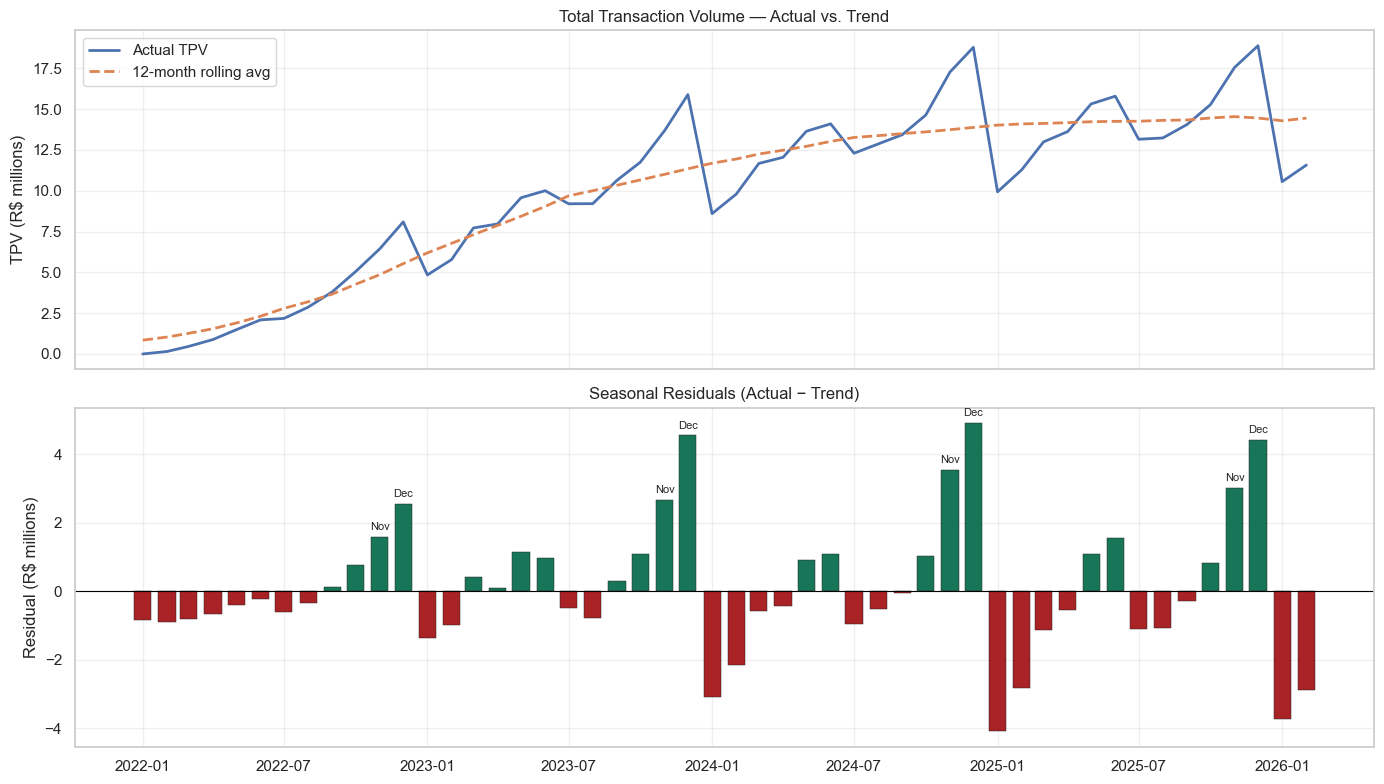

Seasonal month residuals (average across all years):
month_label
Dec     R$4.11M
Feb    R$-1.94M
Jan    R$-2.62M
Nov     R$2.70M


In [54]:
# Monthly TPV
monthly_tpv = (
    df_tx[df_tx["status"] == "completed"]
    .groupby("transaction_month")["amount"]
    .sum()
    .reset_index(name="total_tpv")
    .sort_values("transaction_month")
)

monthly_tpv["rolling_avg"] = monthly_tpv["total_tpv"].rolling(window=12, center=True, min_periods=6).mean()
monthly_tpv["residual"] = monthly_tpv["total_tpv"] - monthly_tpv["rolling_avg"]
monthly_tpv["month_label"] = monthly_tpv["transaction_month"].dt.strftime("%b")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly_tpv["transaction_month"], monthly_tpv["total_tpv"] / 1e6, 
             color="#4C72B0", linewidth=2, label="Actual TPV")
axes[0].plot(monthly_tpv["transaction_month"], monthly_tpv["rolling_avg"] / 1e6, 
             color="#DD8452", linestyle="--", linewidth=2, label="12-month rolling avg")
axes[0].set_ylabel("TPV (R$ millions)")
axes[0].set_title("Total Transaction Volume — Actual vs. Trend")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(
    monthly_tpv["transaction_month"],
    monthly_tpv["residual"] / 1e6,
    width=pd.Timedelta(days=22),
    color=monthly_tpv["residual"].apply(lambda x: "#0B6E4F" if x >= 0 else "#A4161A"),
    edgecolor="#222222",
    linewidth=0.35,
    alpha=0.95,
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Residual (R$ millions)")
axes[1].set_title("Seasonal Residuals (Actual − Trend)")
axes[1].grid(alpha=0.3)

# Annotate Nov/Dec spikes
for _, row in monthly_tpv[monthly_tpv["month_label"].isin(["Nov", "Dec"])].iterrows():
    if not pd.isna(row["residual"]):
        axes[1].annotate(row["month_label"], (row["transaction_month"], row["residual"] / 1e6),
                        textcoords="offset points", xytext=(0, 5), ha="center", fontsize=8)

plt.tight_layout()
plt.show()

seasonal_months = monthly_tpv[monthly_tpv["month_label"].isin(["Nov", "Dec", "Jan", "Feb"])]
print("Seasonal month residuals (average across all years):")
print(seasonal_months.groupby("month_label")["residual"].mean().apply(lambda x: f"R${x/1e6:.2f}M").to_string())


**Insight**: Positive residuals in Nov/Dec confirm Brazilian seasonality (13th salary + Black Friday). 
The magnitude hints at how sensitive the active base is. This establishes a seasonality baseline 
that will inform whether customer segments respond differently.


### 3.3 — Activation Quality Tiers: Does early activation predict long-term retention? <a id="h33"></a>
> We classify each customer by when they made their first transaction relative to registration.
> Hypothesis: customers who activate in M0 retain dramatically better at M6 than late activators.


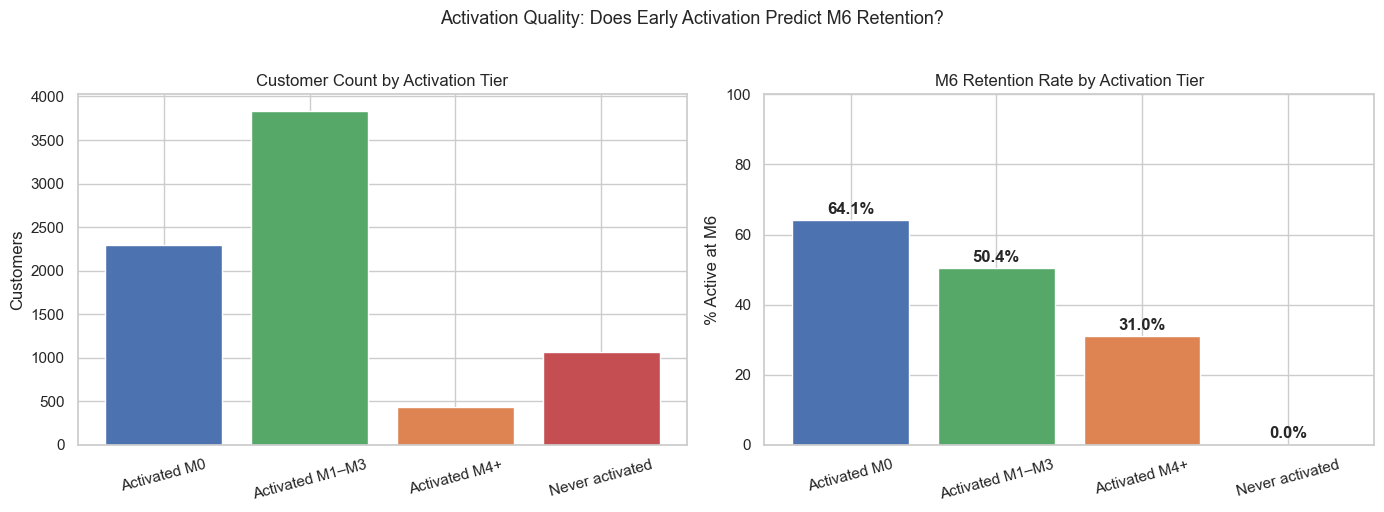

activation_tier  total m6_retention_rate
   Activated M0   2294              64.1
Activated M1–M3   3832              50.4
  Activated M4+    439              31.0
Never activated   1071               0.0


In [56]:
# First transaction month per customer
first_tx = (
    df_tx[df_tx["status"] == "completed"]
    .groupby("customer_id")["transaction_month"]
    .min()
    .reset_index(name="first_tx_month")
)

activation = df_customers[["customer_id", "registration_date"]].merge(first_tx, on="customer_id", how="left")
reg_dates = pd.to_datetime(activation["registration_date"])
if reg_dates.dt.tz is not None:
    reg_dates = reg_dates.dt.tz_convert(None)
activation["reg_month"] = reg_dates.dt.to_period("M").dt.to_timestamp()
activation["months_to_activate"] = (
    (activation["first_tx_month"] - activation["reg_month"]).dt.days / 30.44
).round(0)

def activation_tier(m):
    if pd.isna(m):
        return "Never activated"
    elif m <= 0.5:
        return "Activated M0"
    elif m <= 3:
        return "Activated M1\u2013M3"
    else:
        return "Activated M4+"

activation["activation_tier"] = activation["months_to_activate"].apply(activation_tier)

# M6 activity: was the customer active in month 6 after registration?
activation["m6_month"] = activation["reg_month"] + pd.DateOffset(months=6)

# Only customers with enough tenure for M6 (registered ≥ 6 months ago)
reference_date = pd.Timestamp(df_tx["transaction_month"].max())
if reference_date.tzinfo is not None:
    reference_date = reference_date.tz_convert(None)
analysis_cutoff = reference_date - pd.DateOffset(months=6)
activation_cohort = activation[activation["reg_month"] <= analysis_cutoff].copy()

tx_by_customer_month = (
    df_tx[df_tx["status"] == "completed"]
    .groupby(["customer_id", "transaction_month"])
    .size()
    .reset_index(name="tx_count")
)

# Robust month-key match (avoids string/Timestamp formatting mismatches)
tx_by_customer_month["tx_month_key"] = pd.to_datetime(
    tx_by_customer_month["transaction_month"]
).dt.to_period("M")
activation_cohort["m6_month_key"] = pd.to_datetime(
    activation_cohort["m6_month"]
).dt.to_period("M")

m6_flags = (
    tx_by_customer_month[["customer_id", "tx_month_key"]]
    .drop_duplicates()
    .assign(m6_active=True)
)
activation_cohort = activation_cohort.merge(
    m6_flags,
    how="left",
    left_on=["customer_id", "m6_month_key"],
    right_on=["customer_id", "tx_month_key"],
)
activation_cohort["m6_active"] = activation_cohort["m6_active"].fillna(False)
activation_cohort = activation_cohort.drop(columns=["tx_month_key", "m6_month_key"])

tier_retention = (
    activation_cohort.groupby("activation_tier")["m6_active"]
    .agg(["sum", "count"])
    .reset_index()
)
tier_retention.columns = ["activation_tier", "active_at_m6", "total"]
tier_retention["m6_retention_rate"] = (tier_retention["active_at_m6"] / tier_retention["total"] * 100).round(1)

tier_order = ["Activated M0", "Activated M1\u2013M3", "Activated M4+", "Never activated"]
tier_retention["activation_tier"] = pd.Categorical(tier_retention["activation_tier"], categories=tier_order, ordered=True)
tier_retention = tier_retention.sort_values("activation_tier")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]
axes[0].bar(tier_retention["activation_tier"], tier_retention["total"], color=colors[:len(tier_retention)], edgecolor="white")
axes[0].set_title("Customer Count by Activation Tier")
axes[0].set_ylabel("Customers")
axes[0].tick_params(axis="x", rotation=15)

bars = axes[1].bar(tier_retention["activation_tier"], tier_retention["m6_retention_rate"], color=colors[:len(tier_retention)], edgecolor="white")
axes[1].set_title("M6 Retention Rate by Activation Tier")
axes[1].set_ylabel("% Active at M6")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=15)
for bar, val in zip(bars, tier_retention["m6_retention_rate"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", va="bottom", fontweight="bold")

plt.suptitle("Activation Quality: Does Early Activation Predict M6 Retention?", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(tier_retention[["activation_tier", "total", "m6_retention_rate"]].to_string(index=False))


**Hypothesis confirmed:** Early activation is a strong predictor of medium-term retention. In this cut, **M6 retention declines monotonically by activation speed**: **Activated M0 = 64.1%**, **Activated M1–M3 = 50.4%**, **Activated M4+ = 31.0%**, **Never activated = 0.0%**.

**Business insight:** `activation_tier` is a practical early-warning KPI for commercial and CRM teams. Customers who do not activate in the first month are already on a materially weaker trajectory by M6, so onboarding should prioritize **time-to-first-successful-transaction** (first 7–30 days), with targeted nudges/win-back for late activators before they migrate to the low-retention tiers.


### 3.4 — Recency-Based Risk Tiers: Where are the natural churn risk breaks? <a id="h34"></a>
> Days since last transaction is the simplest churn proxy. We plot its distribution 
> and identify natural breaks to define risk tiers without using any segment labels.


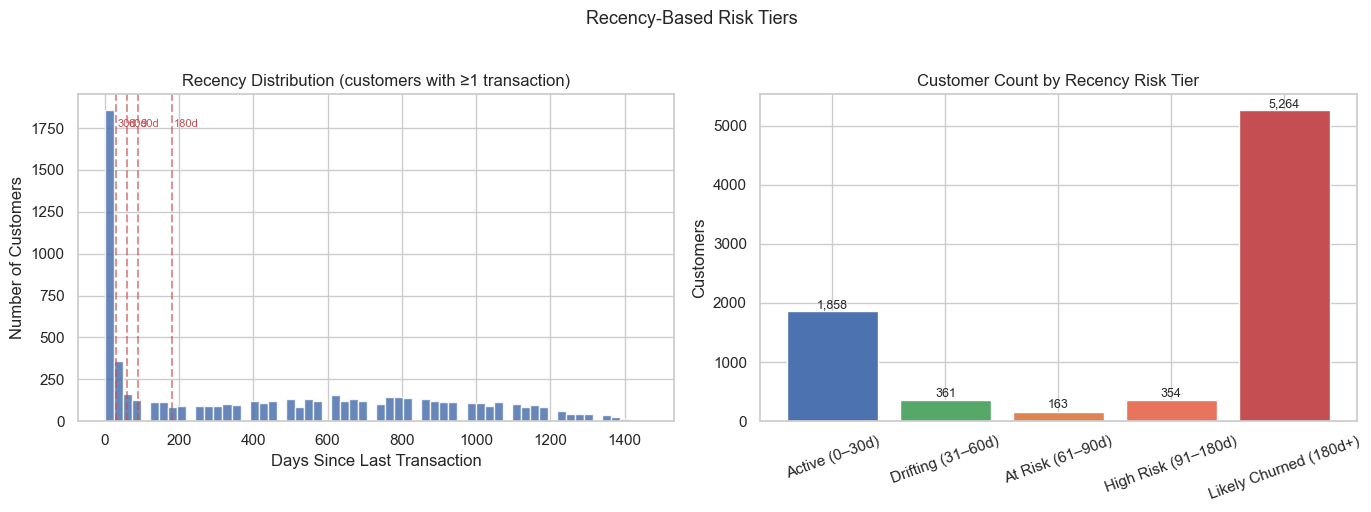


Customers by recency tier:
  Active (0–30d): 1,858 (23.2%)
  Drifting (31–60d): 361 (4.5%)
  At Risk (61–90d): 163 (2.0%)
  High Risk (91–180d): 354 (4.4%)
  Likely Churned (180d+): 5,264 (65.8%)

Customers who never transacted: 1,181


In [58]:
# Days since last transaction per customer (as of reference_date)
last_tx = (
    df_tx[df_tx["status"] == "completed"]
    .groupby("customer_id")["transaction_month"]
    .max()
    .reset_index(name="last_tx_month")
)

recency = df_customers[["customer_id"]].merge(last_tx, on="customer_id", how="left")
recency["days_since_last_tx"] = (
    (reference_date - recency["last_tx_month"]).dt.days
)
recency["days_since_last_tx"] = recency["days_since_last_tx"].fillna(9999)  # never transacted

def recency_tier(d):
    if d <= 30:
        return "Active (0\u201330d)"
    elif d <= 60:
        return "Drifting (31\u201360d)"
    elif d <= 90:
        return "At Risk (61\u201390d)"
    elif d <= 180:
        return "High Risk (91\u2013180d)"
    else:
        return "Likely Churned (180d+)"

recency["recency_tier"] = recency["days_since_last_tx"].apply(recency_tier)

tier_order_r = ["Active (0\u201330d)", "Drifting (31\u201360d)", "At Risk (61\u201390d)", "High Risk (91\u2013180d)", "Likely Churned (180d+)"]
tier_counts = recency["recency_tier"].value_counts().reindex(tier_order_r).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(recency[recency["days_since_last_tx"] < 9999]["days_since_last_tx"], 
             bins=60, color="#4C72B0", edgecolor="white", alpha=0.85)
for threshold in [30, 60, 90, 180]:
    axes[0].axvline(threshold, color="#C44E52", linestyle="--", alpha=0.6)
axes[0].set_xlabel("Days Since Last Transaction")
axes[0].set_ylabel("Number of Customers")
axes[0].set_title("Recency Distribution (customers with \u22651 transaction)")
axes[0].text(35, axes[0].get_ylim()[1]*0.9, "30d", color="#C44E52", fontsize=8)
axes[0].text(65, axes[0].get_ylim()[1]*0.9, "60d", color="#C44E52", fontsize=8)
axes[0].text(95, axes[0].get_ylim()[1]*0.9, "90d", color="#C44E52", fontsize=8)
axes[0].text(185, axes[0].get_ylim()[1]*0.9, "180d", color="#C44E52", fontsize=8)

colors_r = ["#4C72B0", "#55A868", "#DD8452", "#E8745E", "#C44E52"]
bars = axes[1].bar(tier_counts.index, tier_counts.values, color=colors_r, edgecolor="white")
axes[1].set_title("Customer Count by Recency Risk Tier")
axes[1].set_ylabel("Customers")
axes[1].tick_params(axis="x", rotation=20)
for bar, val in zip(bars, tier_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{int(val):,}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Recency-Based Risk Tiers", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nCustomers by recency tier:")
for tier, count in tier_counts.items():
    pct = count / len(recency) * 100
    print(f"  {tier}: {int(count):,} ({pct:.1f}%)")
print(f"\nCustomers who never transacted: {(recency['days_since_last_tx'] == 9999).sum():,}")


**Actionable insight**: The "Likely Churned (180d+)" bucket is the commercial manager's 
first intervention target — size and channel composition of this group determines win-back priority.
The natural breaks in the recency histogram confirm these thresholds are behaviorally meaningful, 
not arbitrary.


### 3.5 — Frequency Quality Tiers: Natural breaks in transaction frequency <a id="h35"></a>
> Per-customer average monthly transaction count, segmented by percentile breaks. 
> Cross with acquisition channel to understand which channels produce high-frequency customers.


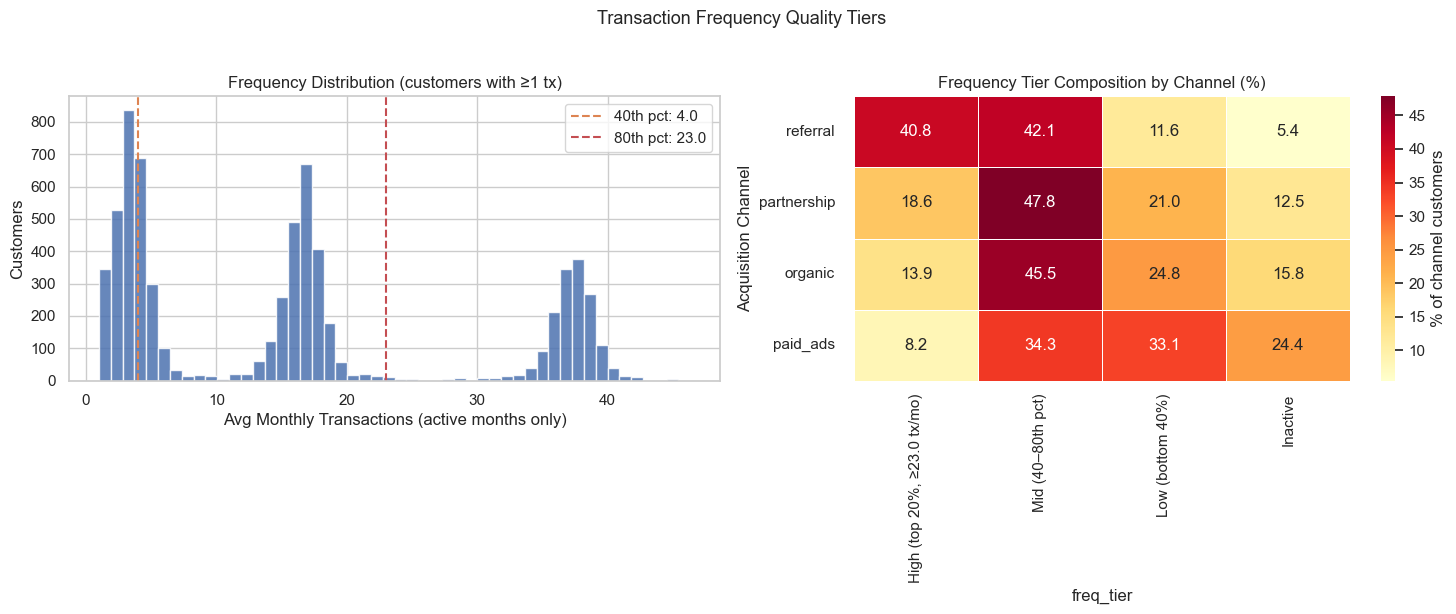

In [62]:
# Average monthly transaction count per customer (active months only)
monthly_tx_counts = (
    df_tx[df_tx["status"] == "completed"]
    .groupby(["customer_id", "transaction_month"])
    .size()
    .reset_index(name="monthly_count")
)
avg_freq = (
    monthly_tx_counts.groupby("customer_id")["monthly_count"]
    .mean()
    .reset_index(name="avg_monthly_tx")
)

freq_df = df_customers[["customer_id", "acquisition_channel"]].merge(avg_freq, on="customer_id", how="left")
freq_df["avg_monthly_tx"] = freq_df["avg_monthly_tx"].fillna(0)

# Percentile-based tiers
p20 = freq_df["avg_monthly_tx"].quantile(0.80)  # top 20%
p60 = freq_df["avg_monthly_tx"].quantile(0.40)  # middle 40\u201380th pct

def freq_tier(f):
    if f == 0:
        return "Inactive"
    elif f >= p20:
        return f"High (top 20%, \u2265{p20:.1f} tx/mo)"
    elif f >= p60:
        return f"Mid (40\u201380th pct)"
    else:
        return f"Low (bottom 40%)"

freq_df["freq_tier"] = freq_df["avg_monthly_tx"].apply(freq_tier)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.05, 1]})

axes[0].hist(freq_df[freq_df["avg_monthly_tx"] > 0]["avg_monthly_tx"], 
             bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(p60, color="#DD8452", linestyle="--", label=f"40th pct: {p60:.1f}")
axes[0].axvline(p20, color="#C44E52", linestyle="--", label=f"80th pct: {p20:.1f}")
axes[0].set_xlabel("Avg Monthly Transactions (active months only)")
axes[0].set_ylabel("Customers")
axes[0].set_title("Frequency Distribution (customers with \u22651 tx)")
axes[0].legend()

# Channel x frequency tier heatmap
channel_freq = (
    freq_df.groupby(["acquisition_channel", "freq_tier"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

# Reorder columns by activity level: High -> Mid -> Low -> Inactive.
high_col = next((c for c in channel_freq.columns if str(c).startswith("High")), None)
mid_col = next((c for c in channel_freq.columns if str(c).startswith("Mid")), None)
low_col = next((c for c in channel_freq.columns if str(c).startswith("Low")), None)
inactive_col = next((c for c in channel_freq.columns if str(c).startswith("Inactive")), None)
col_order = [c for c in [high_col, mid_col, low_col, inactive_col] if c is not None]
if col_order:
    channel_freq = channel_freq[col_order]

# Order channels from highest to lowest overall activity quality (weighted score).
if high_col and mid_col and low_col and inactive_col:
    activity_score = (
        channel_freq[high_col] * 3
        + channel_freq[mid_col] * 2
        + channel_freq[low_col] * 1
        + channel_freq[inactive_col] * 0
    )
    channel_freq = channel_freq.loc[activity_score.sort_values(ascending=False).index]
elif high_col:
    channel_freq = channel_freq.sort_values(by=high_col, ascending=False)

import seaborn as sns
sns.heatmap(
    channel_freq,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    ax=axes[1],
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "% of channel customers"},
)
axes[1].set_title("Frequency Tier Composition by Channel (%)")
axes[1].set_ylabel("Acquisition Channel")
axes[1].set_xlabel("freq_tier")
axes[1].tick_params(axis="y", labelrotation=0, pad=8)
axes[1].tick_params(axis="x", labelrotation=90)

plt.suptitle("Transaction Frequency Quality Tiers", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Business takeaway:** This view separates **traffic volume** from **usage quality**. The histogram defines behavior tiers (High / Mid / Low / Inactive), and the heatmap shows each channel's **within-channel mix** of those tiers.

In this run, **referral** has the strongest quality profile (**40.8% High**, only **5.4% Inactive**), while **paid_ads** is weakest (**8.2% High**, **24.4% Inactive**, and a large **Low** block at **33.1%**). **Partnership** and **organic** sit in the middle with heavy **Mid-tier** concentration.

Operationally: treat **referral** as the benchmark playbook, keep **partnership/organic** focused on moving Mid → High, and apply stricter quality guardrails to **paid_ads** (creative/audience/landing optimization, plus spend gates tied to High-tier share and Inactive rate).


### 3.6 — Product Adoption Curves: Does broader product ownership drive retention? <a id="h36"></a>
> We check whether customers who add a second product within their first 3 months 
> have materially better M6 retention — and what the most common first product is.


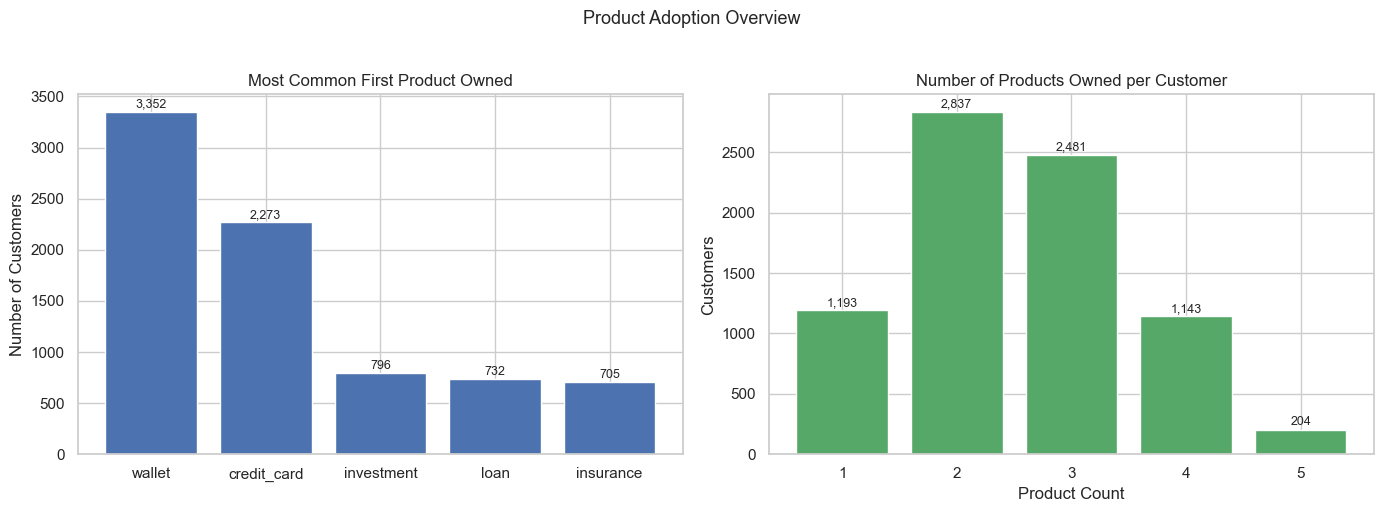

Most common first product: wallet (3,352 customers, 42.7%)
Customers with 2+ products: 6,665 (84.8%)


In [63]:
# Load customer_products_raw (if not already loaded)
try:
    df_cp
except NameError:
    query_cp = "SELECT customer_id, product_id, start_date FROM customer_products_raw"
    df_cp = pd.read_sql(query_cp, engine)
    df_cp["start_date"] = pd.to_datetime(df_cp["start_date"])

# Also load products catalog
try:
    df_products
except NameError:
    df_products = pd.read_sql("SELECT product_id, product_type FROM products_raw", engine)

df_cp_enriched = df_cp.merge(df_products, on="product_id", how="left")
df_cp_enriched = df_cp_enriched.merge(
    df_customers[["customer_id", "registration_date"]], on="customer_id", how="left"
)
df_cp_enriched["registration_date"] = pd.to_datetime(df_cp_enriched["registration_date"])
df_cp_enriched["months_to_product"] = (
    (df_cp_enriched["start_date"] - df_cp_enriched["registration_date"]).dt.days / 30.44
).round(1)

# First product per customer
first_product = (
    df_cp_enriched.sort_values("start_date")
    .groupby("customer_id")
    .first()
    .reset_index()[["customer_id", "product_type"]]
    .rename(columns={"product_type": "first_product"})
)

# Product count per customer
product_count = df_cp_enriched.groupby("customer_id")["product_id"].count().reset_index(name="product_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: first product distribution
first_prod_counts = first_product["first_product"].value_counts()
axes[0].bar(first_prod_counts.index, first_prod_counts.values, color="#4C72B0", edgecolor="white")
axes[0].set_title("Most Common First Product Owned")
axes[0].set_ylabel("Number of Customers")
for bar, val in zip(axes[0].patches, first_prod_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"{val:,}", ha="center", va="bottom", fontsize=9)

# Right: product count distribution
prod_dist = product_count["product_count"].value_counts().sort_index()
axes[1].bar(prod_dist.index, prod_dist.values, color="#55A868", edgecolor="white")
axes[1].set_title("Number of Products Owned per Customer")
axes[1].set_xlabel("Product Count")
axes[1].set_ylabel("Customers")
for bar, val in zip(axes[1].patches, prod_dist.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"{val:,}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Product Adoption Overview", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Most common first product: {first_prod_counts.index[0]} ({first_prod_counts.iloc[0]:,} customers, {first_prod_counts.iloc[0]/len(first_product)*100:.1f}%)")
print(f"Customers with 2+ products: {(product_count['product_count'] >= 2).sum():,} ({(product_count['product_count'] >= 2).mean()*100:.1f}%)")


**Business takeaway:** Product adoption is concentrated in a clear entry path and a strong cross-sell middle.

- **Entry product strategy:** `wallet` is the dominant first product (~3,352 customers, ~43%), followed by `credit_card` (~2,273, ~29%). Together they account for roughly **7 in 10 first touchpoints**, so onboarding and activation should be optimized first for these two journeys.
- **Depth profile:** Most customers sit at **2–3 products owned** (~2,837 and ~2,481 respectively), which suggests cross-sell is already working for a large core base.
- **Upsell gap:** The **1-product** group (~1,193) is a near-term expansion pool; moving this cohort to product #2 is likely the highest-ROI next-product motion.
- **Tail management:** **4–5 product** customers are smaller but high-value candidates for premium bundles, loyalty mechanics, and proactive retention protection.

Operationally, use a staged playbook: (1) maximize wallet/card first-month activation, (2) trigger product-2 nudges by behavior and channel, and (3) treat multi-product customers as a defended value tier.


### 3.7 — Cohort Revenue Curves: Do maturing customers spend more? <a id="h37"></a>
> We track ARPU (average revenue per active user) by tenure month for each acquisition cohort.
> A rising ARPU with tenure signals customers are deepening their engagement over time.


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_29557/2921038561.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_tx_complete["cohort_month"] = df_tx_complete["registration_date"].dt.to_period("M").dt.to_timestamp()
/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_29557/2921038561.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_customers["registration_date"].dt.to_period("M").dt.to_timestamp()


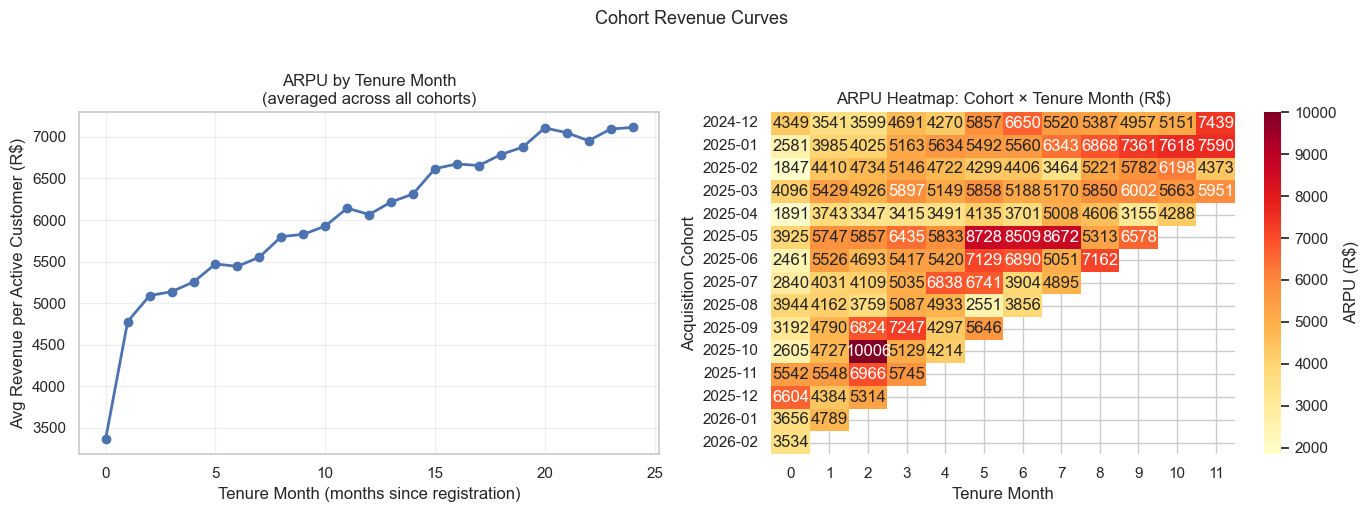

In [64]:
# Cohort x tenure month revenue
df_tx_complete = df_tx[df_tx["status"] == "completed"].copy()
df_tx_complete["cohort_month"] = df_tx_complete["registration_date"].dt.to_period("M").dt.to_timestamp()
df_tx_complete["tenure_month"] = (
    (df_tx_complete["transaction_month"] - df_tx_complete["cohort_month"]).dt.days / 30.44
).round(0).astype(int).clip(lower=0)

# Cohort sizes
cohort_sizes = df_customers.groupby(
    df_customers["registration_date"].dt.to_period("M").dt.to_timestamp()
)["customer_id"].count().rename("cohort_size")

cohort_revenue = (
    df_tx_complete.groupby(["cohort_month", "tenure_month"])
    .agg(total_revenue=("amount", "sum"), active_customers=("customer_id", "nunique"))
    .reset_index()
)
cohort_revenue = cohort_revenue.merge(cohort_sizes, left_on="cohort_month", right_index=True)
cohort_revenue["arpu"] = cohort_revenue["total_revenue"] / cohort_revenue["active_customers"]

# Plot ARPU by tenure month (averaged across all cohorts)
avg_arpu = (
    cohort_revenue[cohort_revenue["tenure_month"] <= 24]
    .groupby("tenure_month")
    .agg(avg_arpu=("arpu", "mean"), cohort_count=("cohort_month", "nunique"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(avg_arpu["tenure_month"], avg_arpu["avg_arpu"], marker="o", color="#4C72B0", linewidth=2)
axes[0].set_xlabel("Tenure Month (months since registration)")
axes[0].set_ylabel("Avg Revenue per Active Customer (R$)")
axes[0].set_title("ARPU by Tenure Month\n(averaged across all cohorts)")
axes[0].grid(alpha=0.3)

# Heatmap: cohort x tenure month for ARPU (recent 12 cohorts x first 12 months)
pivot_arpu = cohort_revenue[cohort_revenue["tenure_month"] <= 11].pivot_table(
    index="cohort_month", columns="tenure_month", values="arpu", aggfunc="mean"
)
# Limit to last 15 cohorts for readability
if len(pivot_arpu) > 15:
    pivot_arpu = pivot_arpu.tail(15)
pivot_arpu.index = pivot_arpu.index.strftime("%Y-%m")

import seaborn as sns
sns.heatmap(pivot_arpu, ax=axes[1], cmap="YlOrRd", fmt=".0f", annot=len(pivot_arpu) <= 15,
            cbar_kws={"label": "ARPU (R$)"})
axes[1].set_title("ARPU Heatmap: Cohort \u00d7 Tenure Month (R$)")
axes[1].set_xlabel("Tenure Month")
axes[1].set_ylabel("Acquisition Cohort")

plt.suptitle("Cohort Revenue Curves", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


These charts suggest a clear customer maturation effect:

ARPU increases with tenure (left chart): average revenue per active customer rises strongly from early months and then levels off around later tenure, so customers tend to spend more as they age.

Cohort consistency with some variability (right heatmap): most cohorts show this same upward pattern across tenure, but some cohorts are stronger/weaker at the same tenure month.

Business meaning: retention + engagement over time are working; the big opportunity is to move more customers from early tenure into the mid/late-tenure zone where ARPU is much higher.

Practical action: focus on first-90-day activation and cross-sell playbooks to accelerate the path to higher-tenure spending behavior

### 3.8 — Churn Proxies: Involuntary vs. voluntary exit signals <a id="h38"></a>
> We examine what kind of transaction precedes a customer going silent — 
> and whether failed/reversed transaction rates increase as customers near the end of their lifecycle.


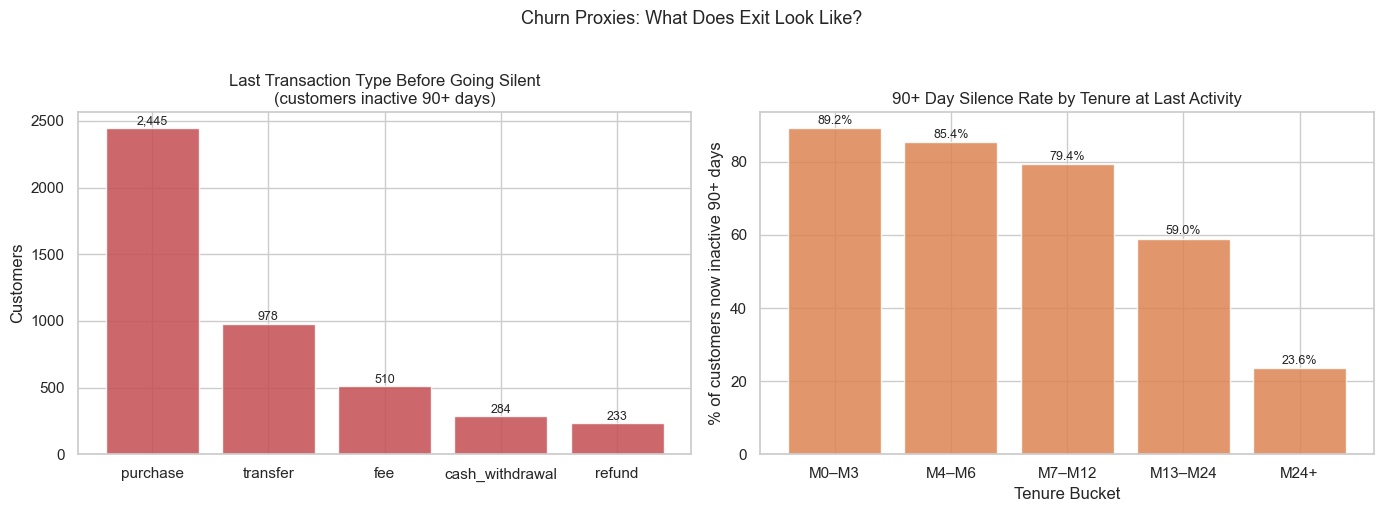


Customers inactive 90+ days: 4,450 (55.6% of base)

Last transaction type before going silent:
last_tx_type
purchase           2445
transfer            978
fee                 510
cash_withdrawal     284
refund              233


In [69]:
# Build an all-status transaction frame (df_tx is often completed-only in this notebook).
try:
    df_tx_all = pd.read_sql(
        "SELECT customer_id, transaction_datetime, transaction_type, status FROM public.transactions_raw",
        engine,
    )
except Exception:
    # Fallback: use in-memory data if DB access is unavailable in this session.
    df_tx_all = df_tx.copy()

# Ensure we have transaction_month for all-status data.
if "transaction_month" not in df_tx_all.columns:
    tx_all_dt = pd.to_datetime(df_tx_all["transaction_datetime"])
    if isinstance(tx_all_dt.dtype, pd.DatetimeTZDtype):
        tx_all_dt = tx_all_dt.dt.tz_convert("UTC").dt.tz_localize(None)
    df_tx_all["transaction_month"] = tx_all_dt.dt.to_period("M").dt.to_timestamp()

# For each customer, find their last transaction (all statuses)
last_tx_all = (
    df_tx_all.sort_values("transaction_month")
    .groupby("customer_id")
    .last()
    .reset_index()[["customer_id", "transaction_type", "status", "transaction_month"]]
    .rename(
        columns={
            "transaction_type": "last_tx_type",
            "status": "last_tx_status",
            "transaction_month": "last_tx_month",
        }
    )
)

# Identify customers who went silent (no transactions in last 90 days)
reference_date_local = pd.Timestamp(df_tx_all["transaction_month"].max())
if reference_date_local.tzinfo is not None:
    reference_date_local = reference_date_local.tz_convert(None)
last_tx_all["days_since_last"] = (reference_date_local - last_tx_all["last_tx_month"]).dt.days
churned_proxy = last_tx_all[last_tx_all["days_since_last"] >= 90].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: last transaction type for churned customers
last_type_dist = churned_proxy["last_tx_type"].value_counts()
axes[0].bar(last_type_dist.index, last_type_dist.values, color="#C44E52", edgecolor="white", alpha=0.85)
axes[0].set_title("Last Transaction Type Before Going Silent\n(customers inactive 90+ days)")
axes[0].set_ylabel("Customers")
for bar, val in zip(axes[0].patches, last_type_dist.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, f"{val:,}", ha="center", va="bottom", fontsize=9)

# Right: 90+ day silence rate by tenure-at-last-activity
last_tx_with_reg = last_tx_all.merge(
    df_customers[["customer_id", "registration_date"]],
    on="customer_id",
    how="left",
)

reg_month = pd.to_datetime(last_tx_with_reg["registration_date"])
if reg_month.dt.tz is not None:
    reg_month = reg_month.dt.tz_convert(None)
reg_month = reg_month.dt.to_period("M").dt.to_timestamp()

last_tx_with_reg["tenure_at_last_tx"] = (
    (pd.to_datetime(last_tx_with_reg["last_tx_month"]) - reg_month).dt.days / 30.44
).clip(lower=0).round(0)

last_tx_with_reg["tenure_bucket"] = pd.cut(
    last_tx_with_reg["tenure_at_last_tx"],
    bins=[0, 3, 6, 12, 24, 9999],
    labels=["M0–M3", "M4–M6", "M7–M12", "M13–M24", "M24+"],
)

silent_ids = set(churned_proxy["customer_id"])
last_tx_with_reg["silent_90d"] = last_tx_with_reg["customer_id"].isin(silent_ids)

silence_rate = (
    last_tx_with_reg.groupby("tenure_bucket")["silent_90d"]
    .mean()
    .mul(100)
    .reset_index(name="silence_rate_pct")
)

axes[1].bar(
    silence_rate["tenure_bucket"].astype(str),
    silence_rate["silence_rate_pct"],
    color="#DD8452",
    edgecolor="white",
    alpha=0.85,
)
axes[1].set_title("90+ Day Silence Rate by Tenure at Last Activity")
axes[1].set_ylabel("% of customers now inactive 90+ days")
axes[1].set_xlabel("Tenure Bucket")
for bar, val in zip(axes[1].patches, silence_rate["silence_rate_pct"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.suptitle("Churn Proxies: What Does Exit Look Like?", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nCustomers inactive 90+ days: {len(churned_proxy):,} ({len(churned_proxy)/len(df_customers)*100:.1f}% of base)")
print("\nLast transaction type before going silent:")
print(last_type_dist.to_string())



Combined read: the left panel describes **how customers exit** (last action type before silence), while the right panel shows **when exits concentrate across lifecycle tenure**.

**Business implications:** (1) Exits are mostly preceded by `purchase`/`transfer`, which suggests churn is often **value/habit decay** rather than purely payment-failure friction. (2) Silence risk is highest in early-tenure buckets (M0–M12), so the strongest retention ROI sits in **first-year lifecycle interventions**. (3) The sharp drop in silence rate for M24+ is a survivor effect: once customers stay long enough, behavior stabilizes and churn propensity falls.

**Actionable focus:** prioritize day-7/day-30/day60 re-engagement triggers, launch pre-90-day win-back journeys, and allocate CRM budget by tenure risk (heavy save pressure for early-tenure, lighter maintenance for mature cohorts).

**Hypothesis for clustering:** customers in tenure buckets with the highest 90+ day silence rates should over-index in lower-engagement clusters in Notebook 3 (high recency, lower frequency/monetary behavior).



<a id="notebook2-closing"></a>

## Notebook summary — business questions & what comes next

[↑ Back to summary](#summary)

### Business questions answered (this notebook)

**Q2 — Which acquisition month produces the most retained customers?**  
**Quality** (highest **M6 active rate**) and **volume** (most **eligible users retained at M6**) often highlight **different** cohort months: early periods can dominate **volume** because cohorts are larger and more users have reached M6; a later month can still win on **rate**. Always read rankings next to **eligible N** — small denominators inflate percentages.

**Q3 — At what month do most customers disengage?**  
On the **aggregate tenure curve**, the **steepest marginal drop** is **M4→M5**. The drop is consistent with delayed first use and gradual disengagement from lower-activity customers. Prioritise re-engagement in the **M4–M5 window** before permanent exit.

**Q4 — Are recent cohorts healthier than older ones?**  
**Not fully discernible from aggregate cohort-month lines alone:** the series is volatile, eligible denominators shrink for recent months, and M6 is undefined for the newest cohorts. Use channel/segment cuts and minimum-N filters before claiming directional improvement.

**Q5 — Which acquisition channel brings the highest quality customers?**  
**Referral** is the most consistent high-quality channel (strong M6/streak and better frequency-mix quality), while **paid_ads** underperforms on downstream engagement quality. This supports channel-level quality guardrails, not only top-of-funnel volume targets.

**Behavioral heterogeneity + Pareto:** customer base is polarized (very low vs very high activity), and revenue is concentrated in a small share of users → protect high-value actives while running targeted activation/win-back for the low-activity tail.
**Seasonality + channels:** Nov/Dec seasonality is visible; **referral** is consistently highest-quality and **paid_ads** weakest on downstream engagement → manage channels with quality guardrails, not only acquisition volume.
**Activation/frequency/product depth:** earlier activation (M0) and stronger frequency tiers map to better M6 outcomes; most customers sit at 2–3 products with wallet/card as entry → prioritize first-30-day activation and product-2 cross-sell motions.
**Recency/churn proxies:** large 90d+/180d+ risk pools and strong early-tenure silence indicate the main retention ROI is in first-year lifecycle interventions (pre-90-day saves, tenure-based CRM).



---

**Where the pipeline goes next**

| Next step | Notebook | How it builds on this work |
|-----------|----------|------------------------------|
| Formal clustering | **Notebook 3** — RFM & K-Means | Use monthly recency / frequency / monetary inputs to build RFM scores and K-Means clusters. The behavioral hypotheses from Part 3 set up the clustering features and expected group structure. |

---
